# Analysis of Splicing Predictions on Assays

1. Liao et al. 2023: synthetic sequence splicing assay
2. Baeza-Centurion et al. 2025: *FAS* exon 6 mutagenesis assay
3. Chong et al. 2019: MFASS assay

## 1. Setup and Imports

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
import scipy.stats
import seaborn as sns
from sklearn.isotonic import IsotonicRegression
import statsmodels.api as sm
import statsmodels.formula.api as smf

# Custom utility modules
import sequence_utils as seq_utils
import plotting_utils as plot_utils

## 2. Data Loading

In [2]:
csv_paths = {
    "liao2023": "../data/Liao_2023_SplicingPredictions.csv.gz",
    "baeza-centurion2025": "../data/Baeza_Centurion_2025_SplicingPredictions.csv.gz",
    "chong2019": "../data/Chong_2019_SplicingPredictions.csv.gz",
}

display_names = {
    "liao2023": "Liao et al. 2023",
    "baeza-centurion2025": "FAS Exon 6",
    "chong2019": "MFASS",
}

assay_data = dict()
for key, path in csv_paths.items():
    assay_data[key] = pd.read_csv(path)

assay_data["liao2023"]["PSI"] = assay_data["liao2023"]["PSI"] * 100

assay_data["baeza-centurion2025"]["exon"] = assay_data["baeza-centurion2025"]["sequence"]
assay_data["baeza-centurion2025"]["PSI"] = assay_data["baeza-centurion2025"]["psi"]

# Filter MFASS only to WT and exonic variant sequences
assay_data["chong2019"] = assay_data["chong2019"].loc[(
    (assay_data["chong2019"]["label"] == "exon") |
    (assay_data["chong2019"]["category"] == "natural")
)]
assay_data["chong2019"]["PSI"] = assay_data["chong2019"]["v2_index"] * 100

## 3. Splicing Predictions

In [3]:
# Add average Pangolin tissue usage score
for key, data in assay_data.items():
    assay_data[key]["pangolin_average_usage_avg"] = (
        assay_data[key]["pangolin_heart_usage_avg"] +
        assay_data[key]["pangolin_liver_usage_avg"] +
        assay_data[key]["pangolin_brain_usage_avg"] +
        assay_data[key]["pangolin_testis_usage_avg"]
    ) / 4

### Calibrate Predictions

In [4]:
def calibrate_isotonic(predictions, labels):
    ir = IsotonicRegression(out_of_bounds='clip')
    ir.fit(predictions, labels)
    return ir.predict

In [5]:
measurement_eps = 1e-3
model_eps = 1e-4

datasets = ["liao2023", "chong2019", "baeza-centurion2025"]
models = ["spliceai_avg", "alphagenome_junctions_psi", "pangolin_average_usage_avg"]

for d in datasets:
    assay_data[d]["PSI_logit_clipped"] = assay_data[d]["PSI"] \
        .apply(lambda x: x / 100) \
        .clip(measurement_eps, 1 - measurement_eps) \
        .apply(scipy.special.logit)

    for m in models:
        assay_data[d][f"{m}_logit"] = assay_data[d][m] \
            .clip(model_eps, 1 - model_eps) \
            .apply(scipy.special.logit)

        calibrator = calibrate_isotonic(
            assay_data[d][f"{m}_logit"],
            assay_data[d][f"PSI_logit_clipped"],
        )

        assay_data[d][f"{m}_logit_calibrated"] = calibrator(
            assay_data[d][f"{m}_logit"],
        )

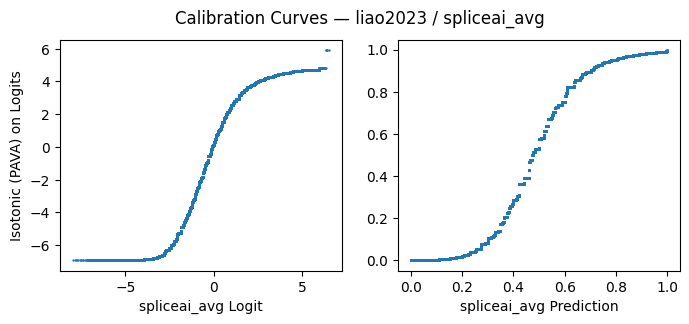

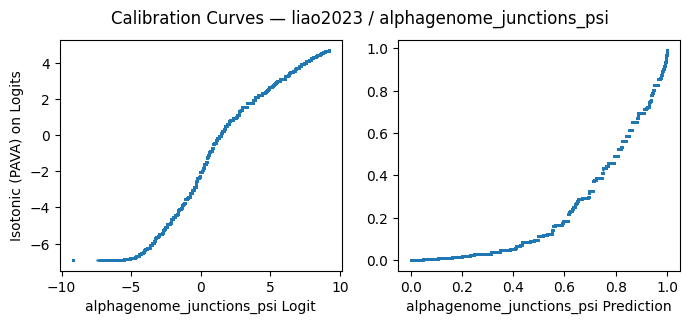

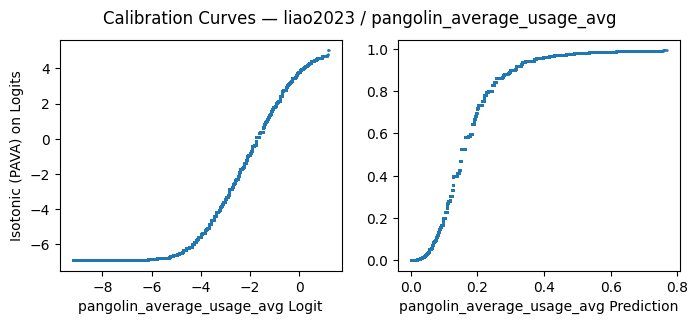

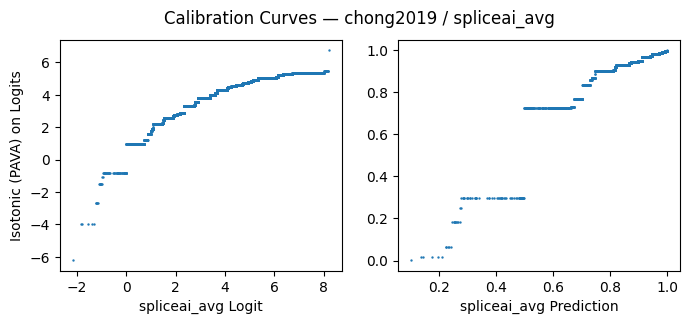

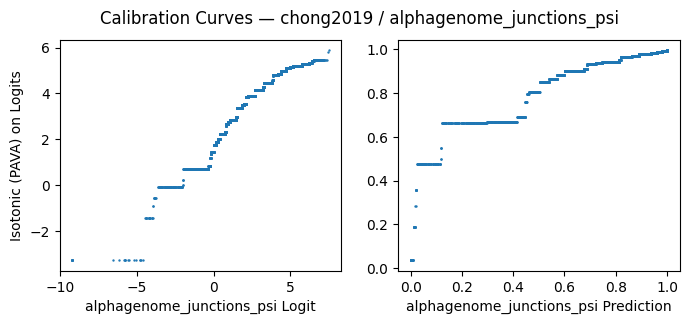

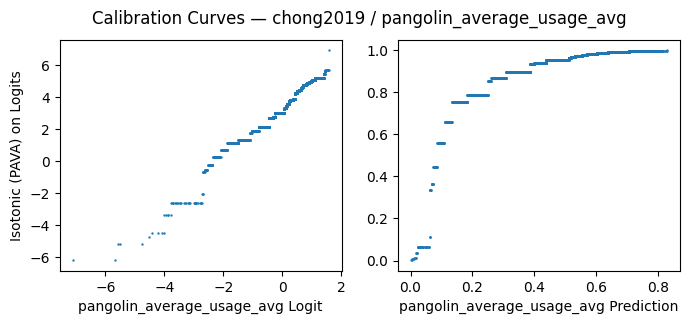

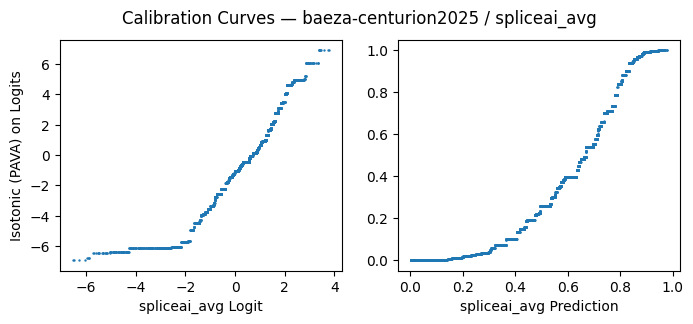

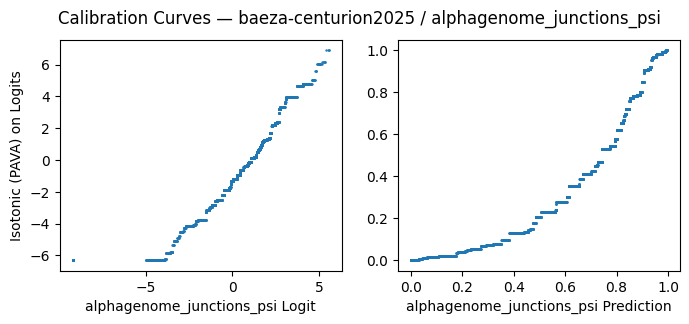

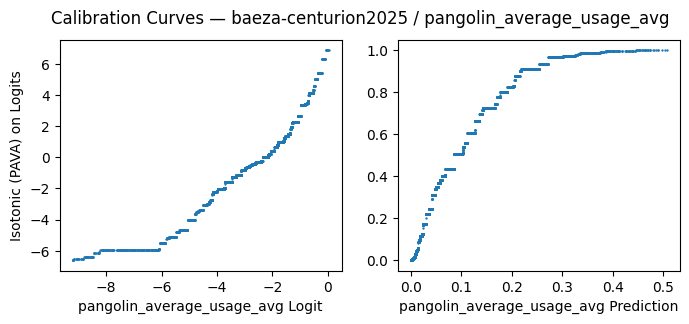

In [6]:
from scipy.special import expit, logit

plot_configs = [                                                                                                                                                         
    {
        "ylabel": "Isotonic (PAVA) on Logits",                                                                                                                           
        "left_x":  lambda m, df: df[f"{m}_logit"],
        "left_y":  lambda m, df: df[f"{m}_logit_calibrated"],
        "right_x": lambda m, df: df[f"{m}"],
        "right_y": lambda m, df: expit(df[f"{m}_logit_calibrated"]),
    },
]

for dataset in datasets:
    for model in models:
        df = assay_data[dataset]
        
        fig, axes = plt.subplots(1, 2, figsize=(8, 3), sharex='col', sharey='col')
        fig.suptitle(f"Calibration Curves — {dataset} / {model}")
        
        for i, config in enumerate(plot_configs):
            axes[0].set_ylabel(config["ylabel"])
            axes[0].scatter(config["left_x"](model, df),  config["left_y"](model, df),  s=0.5)
            axes[1].scatter(config["right_x"](model, df), config["right_y"](model, df), s=0.5)
        
        axes[0].set_xlabel(f"{model} Logit")
        axes[1].set_xlabel(f"{model} Prediction")
        
        fig.subplots_adjust(hspace=0.4)
        plt.show()

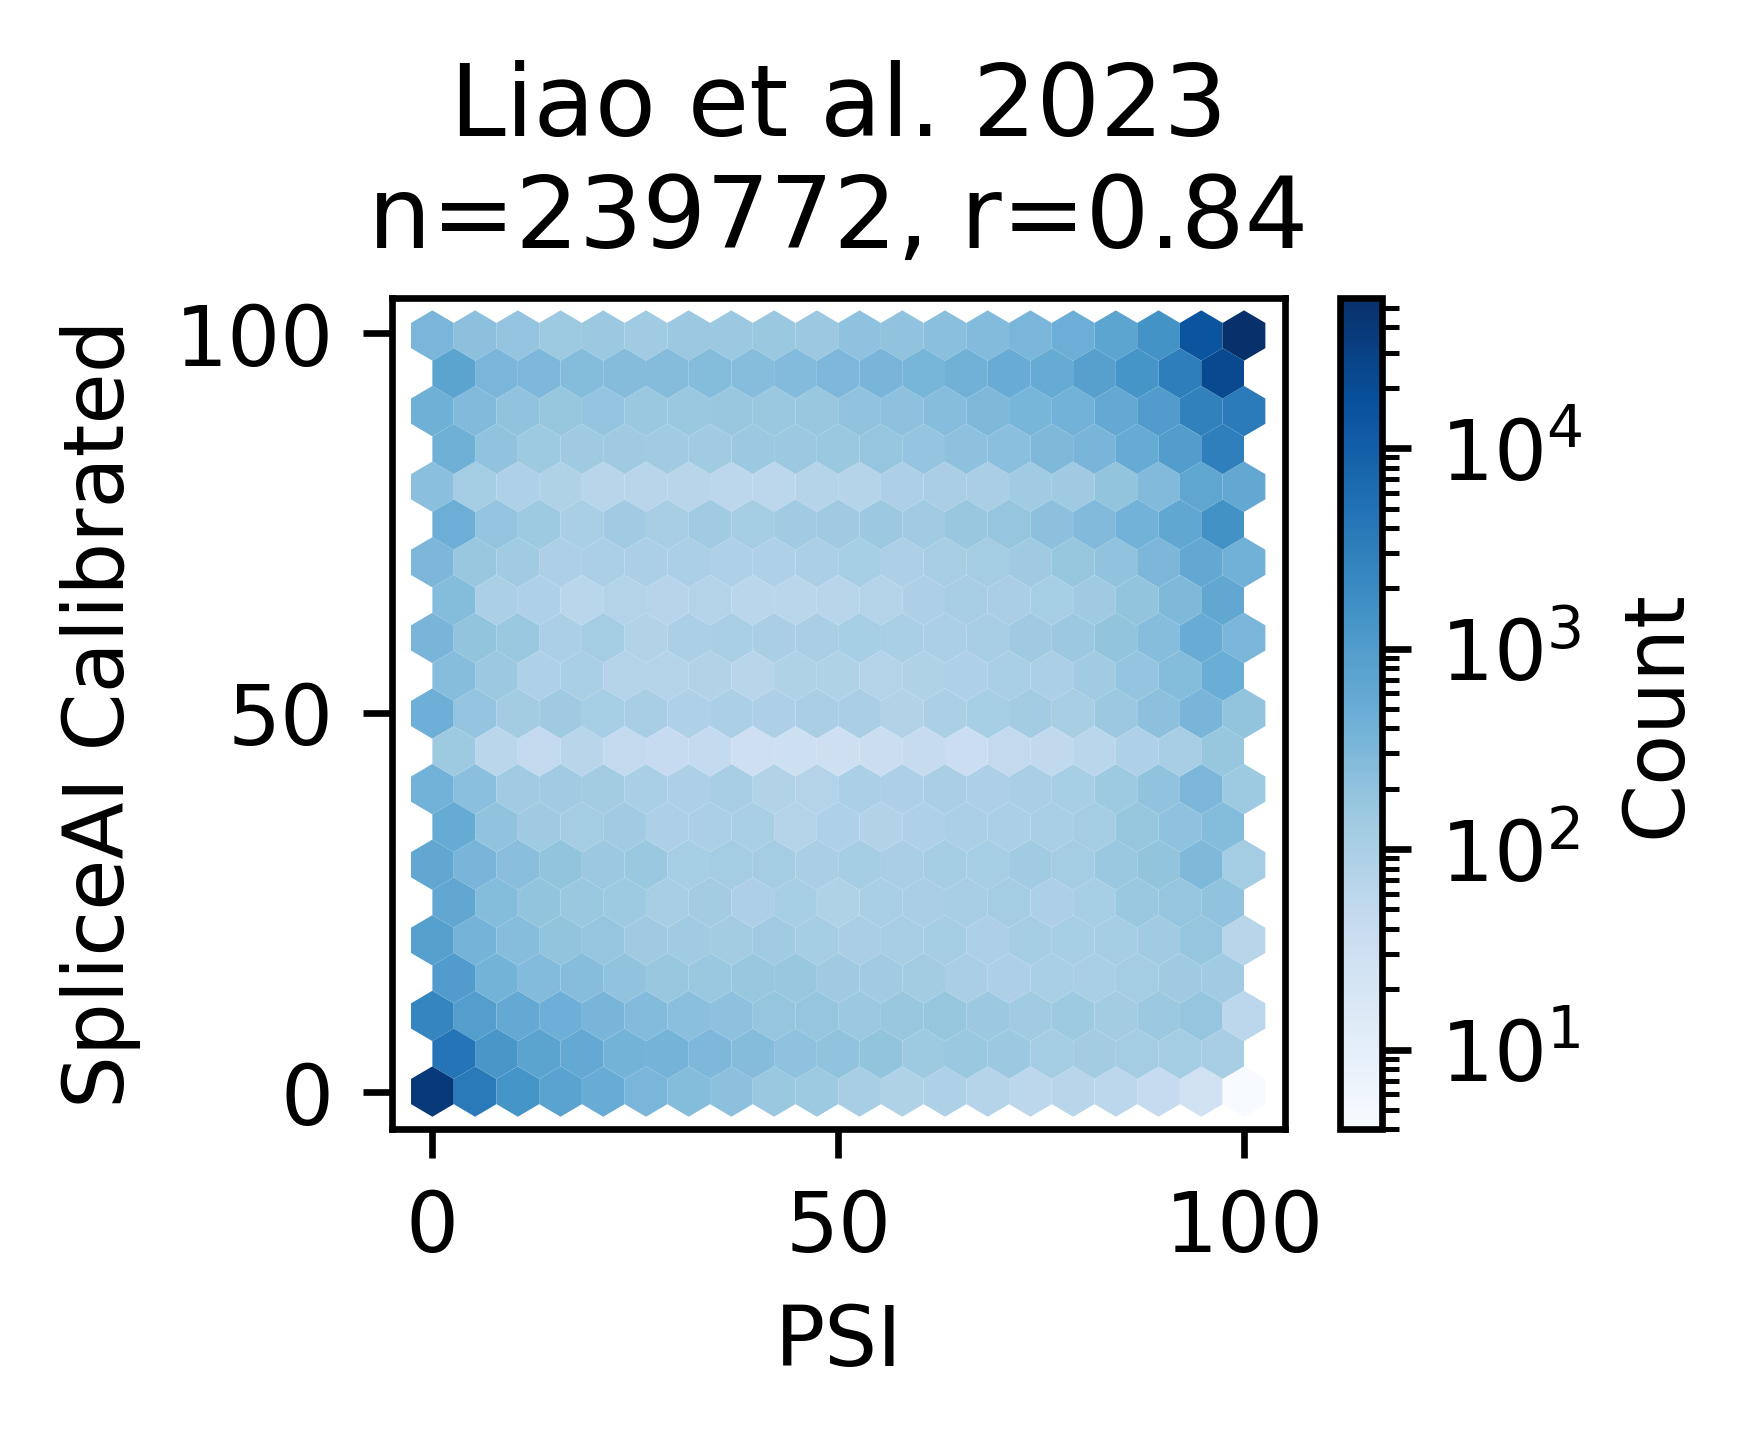

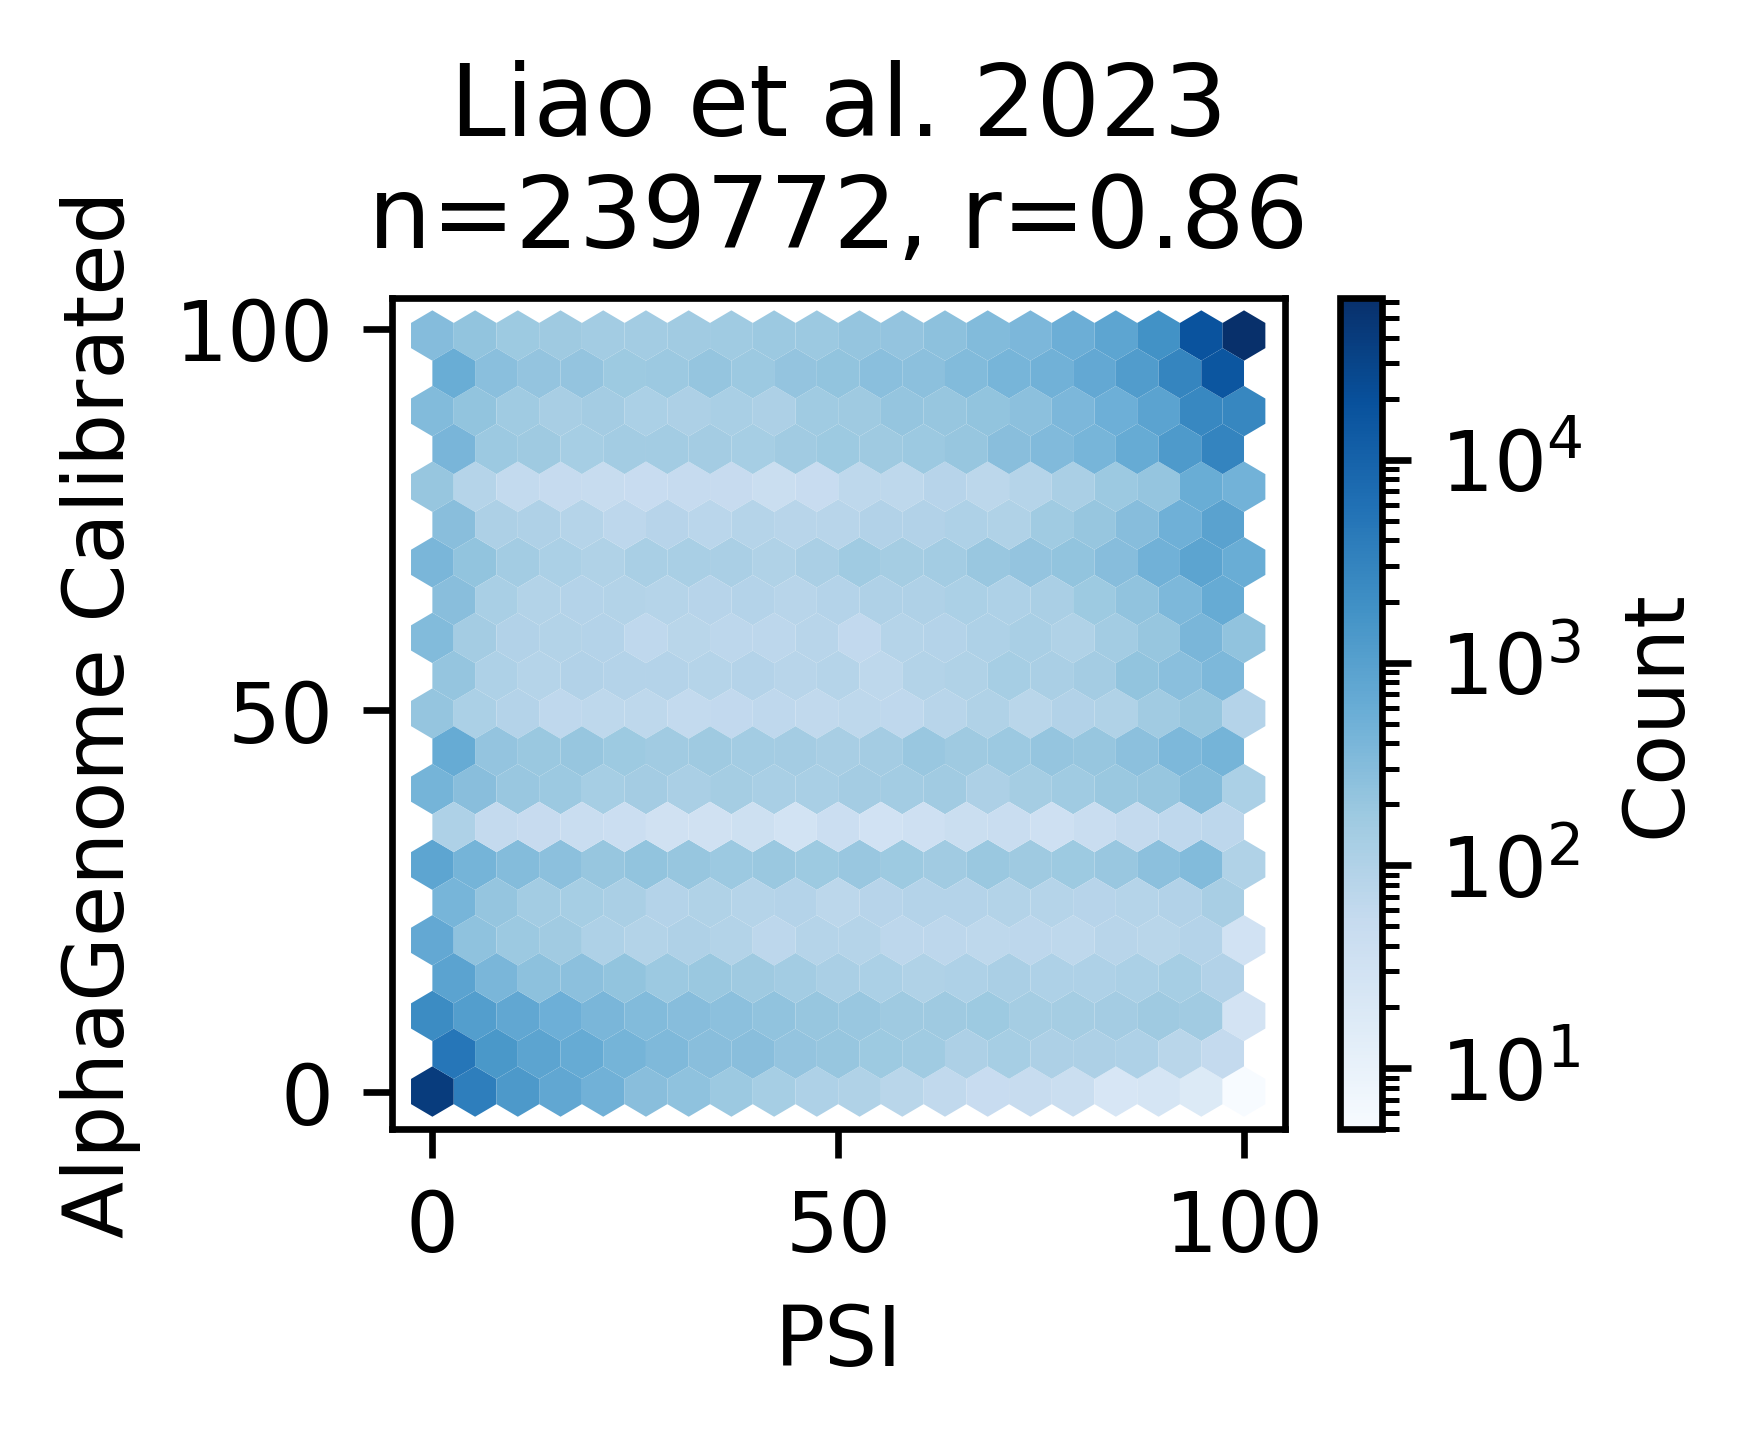

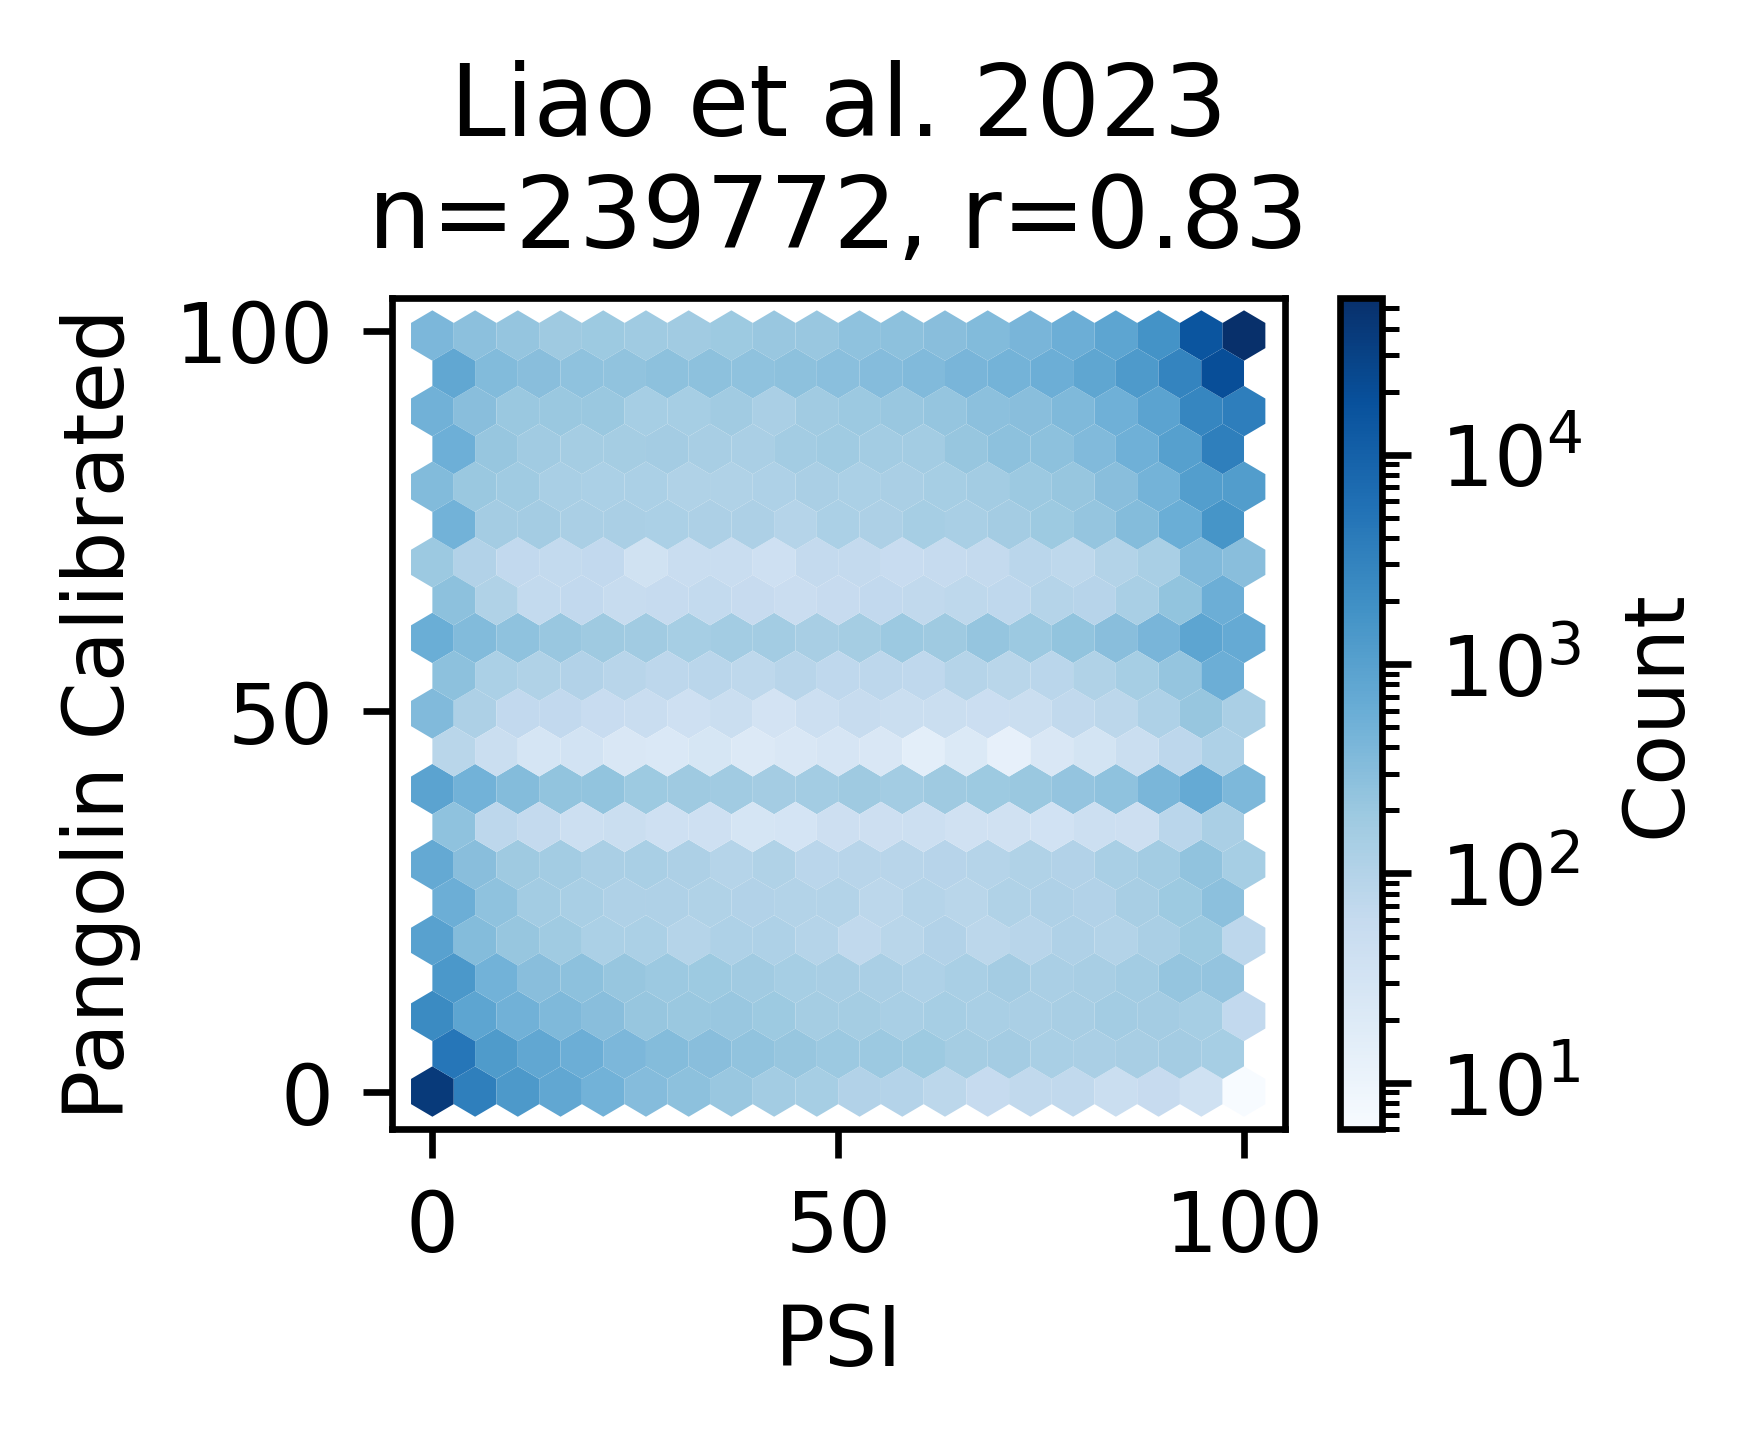

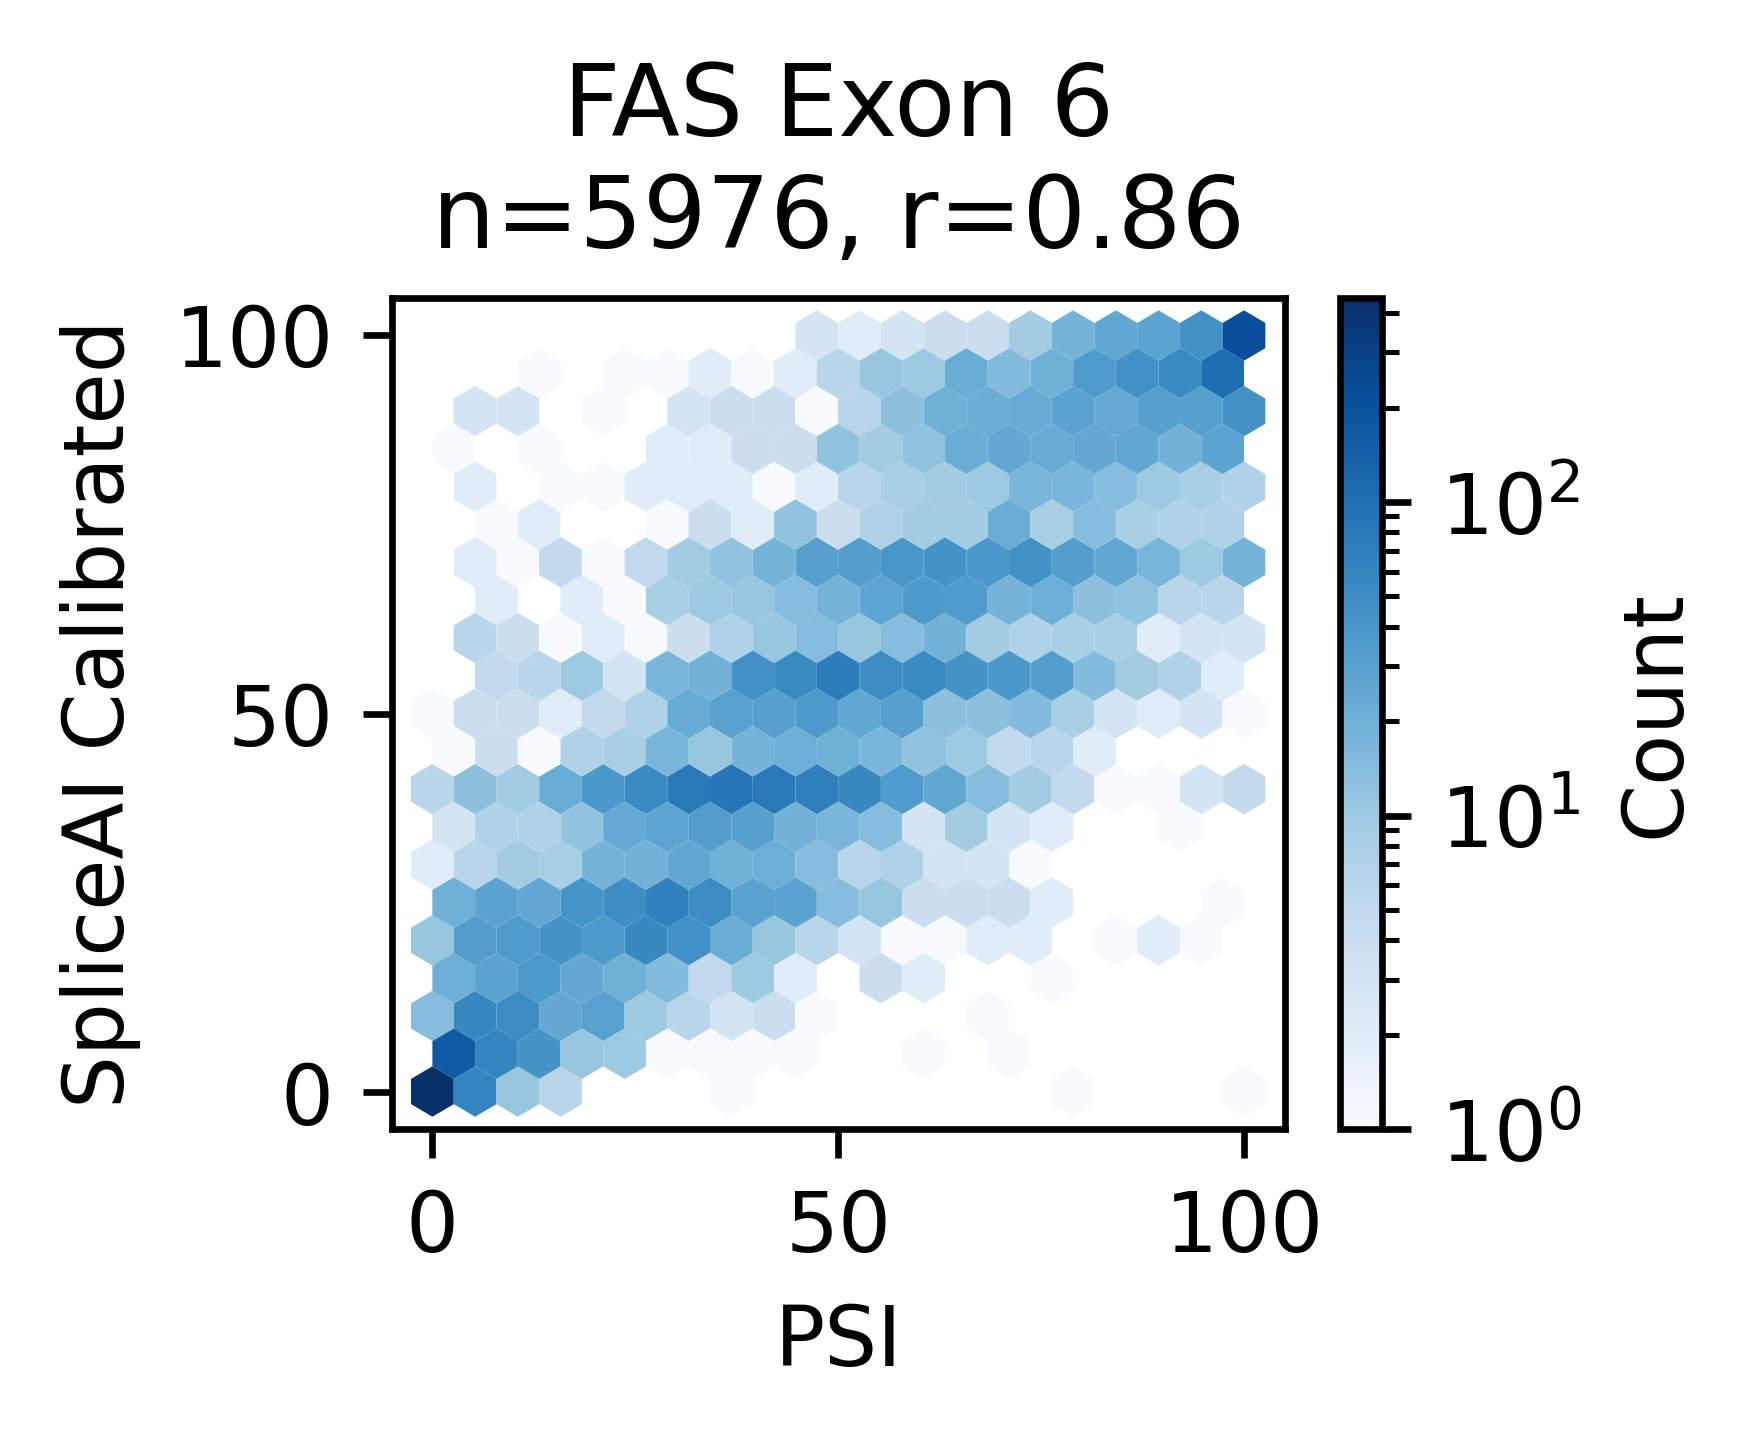

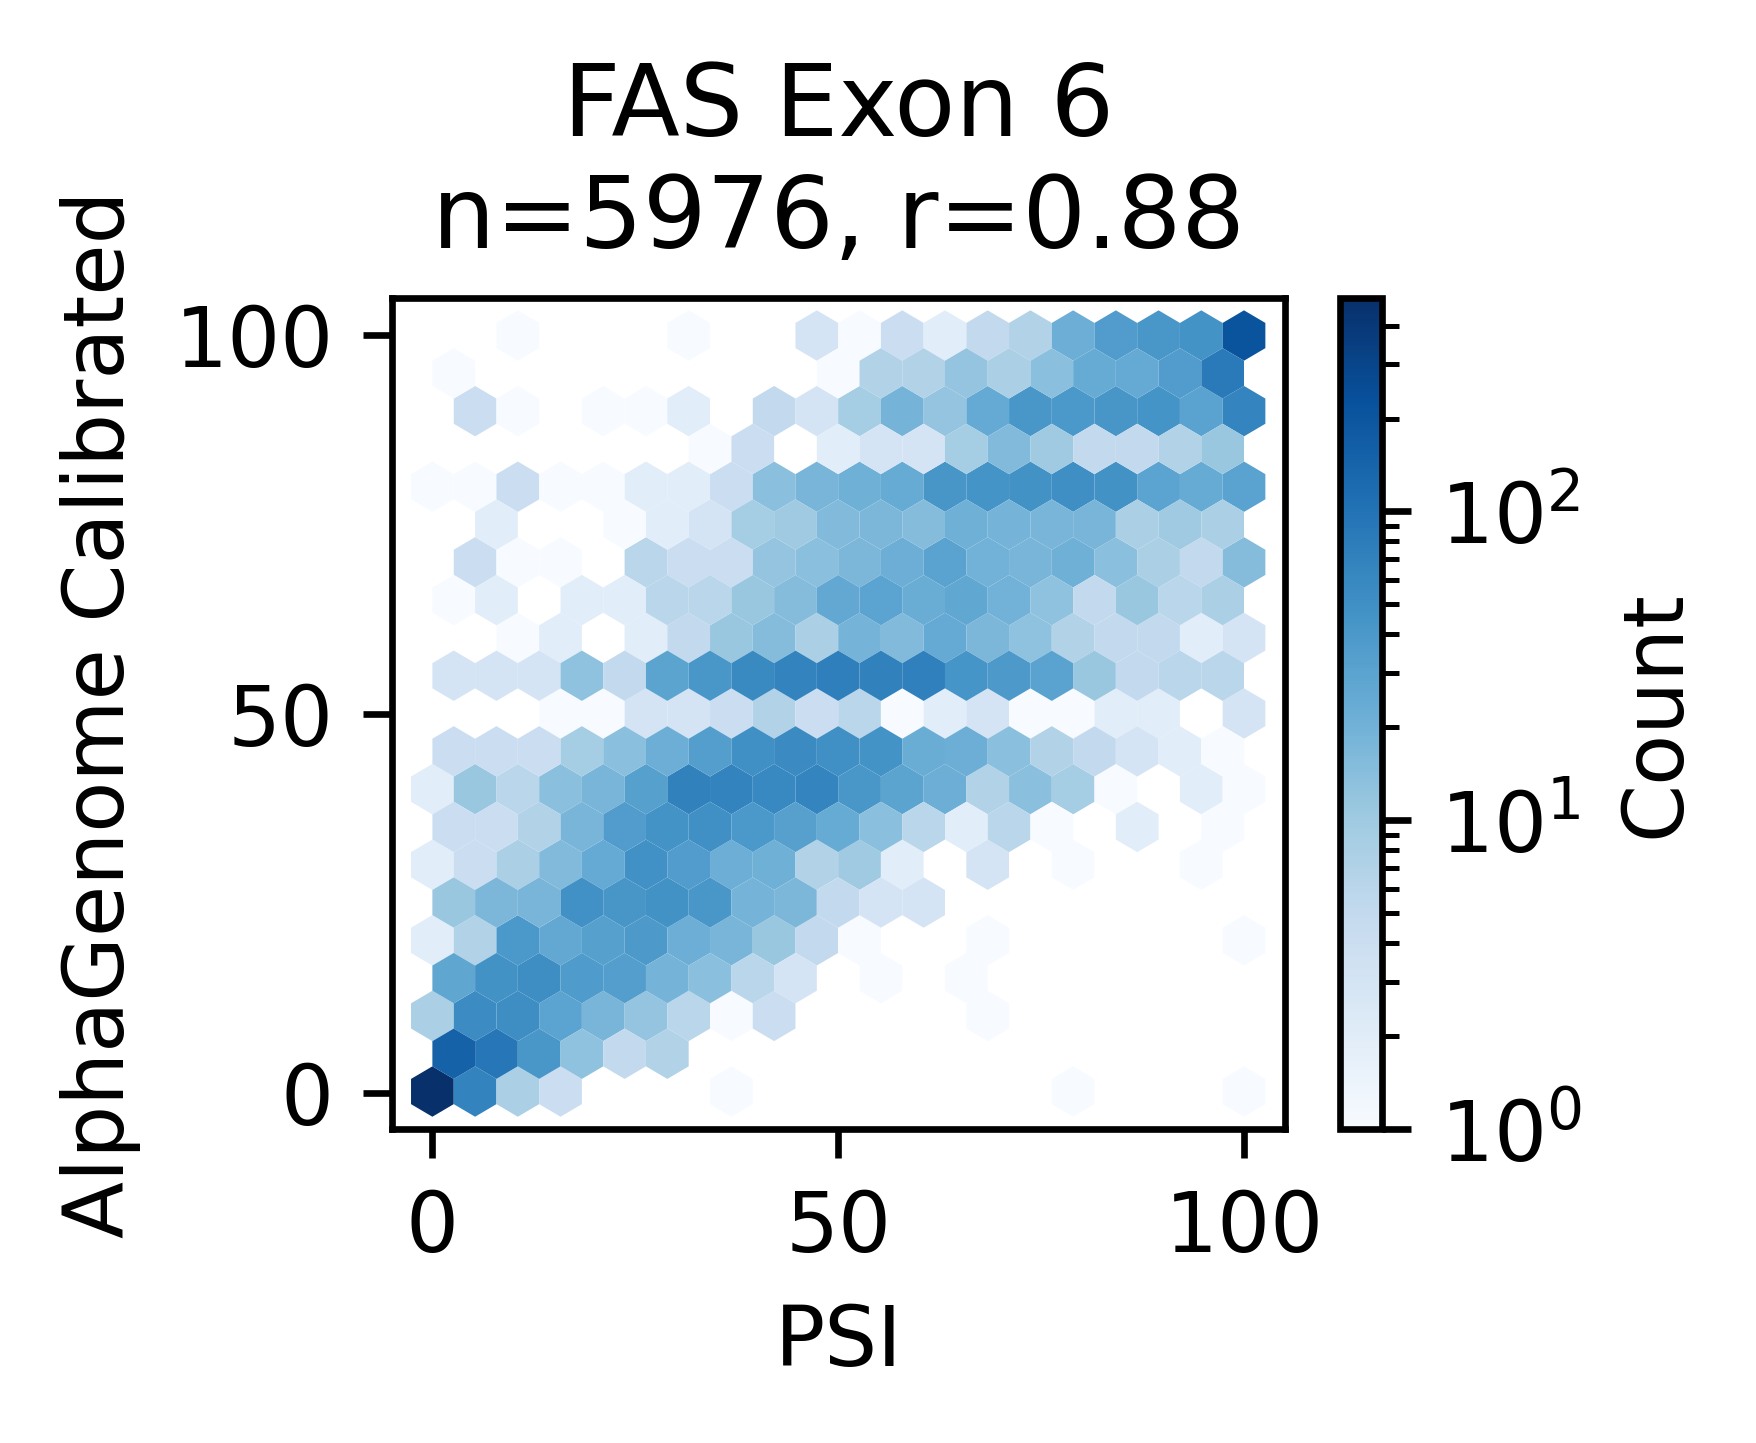

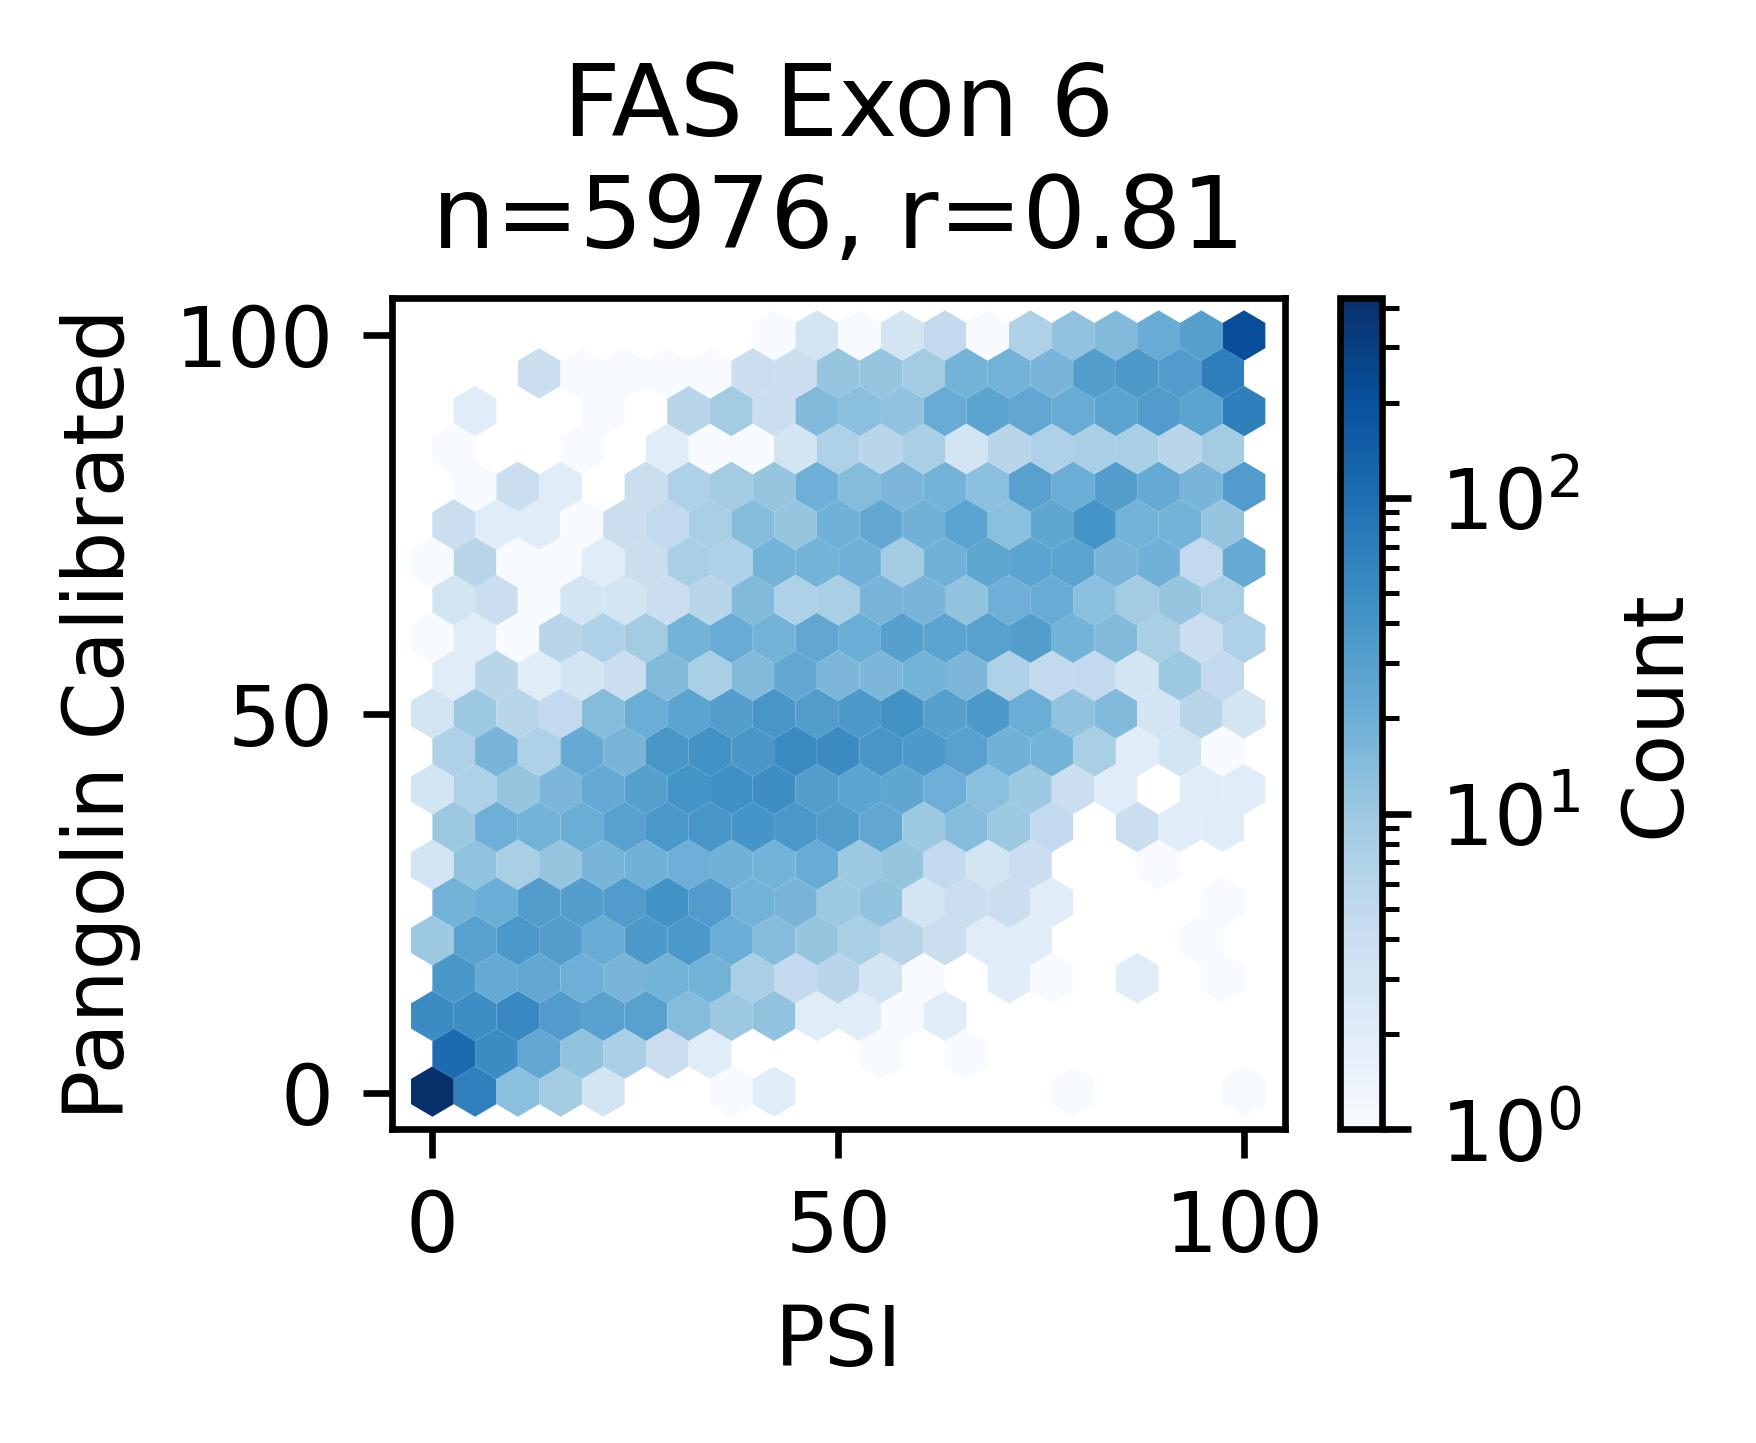

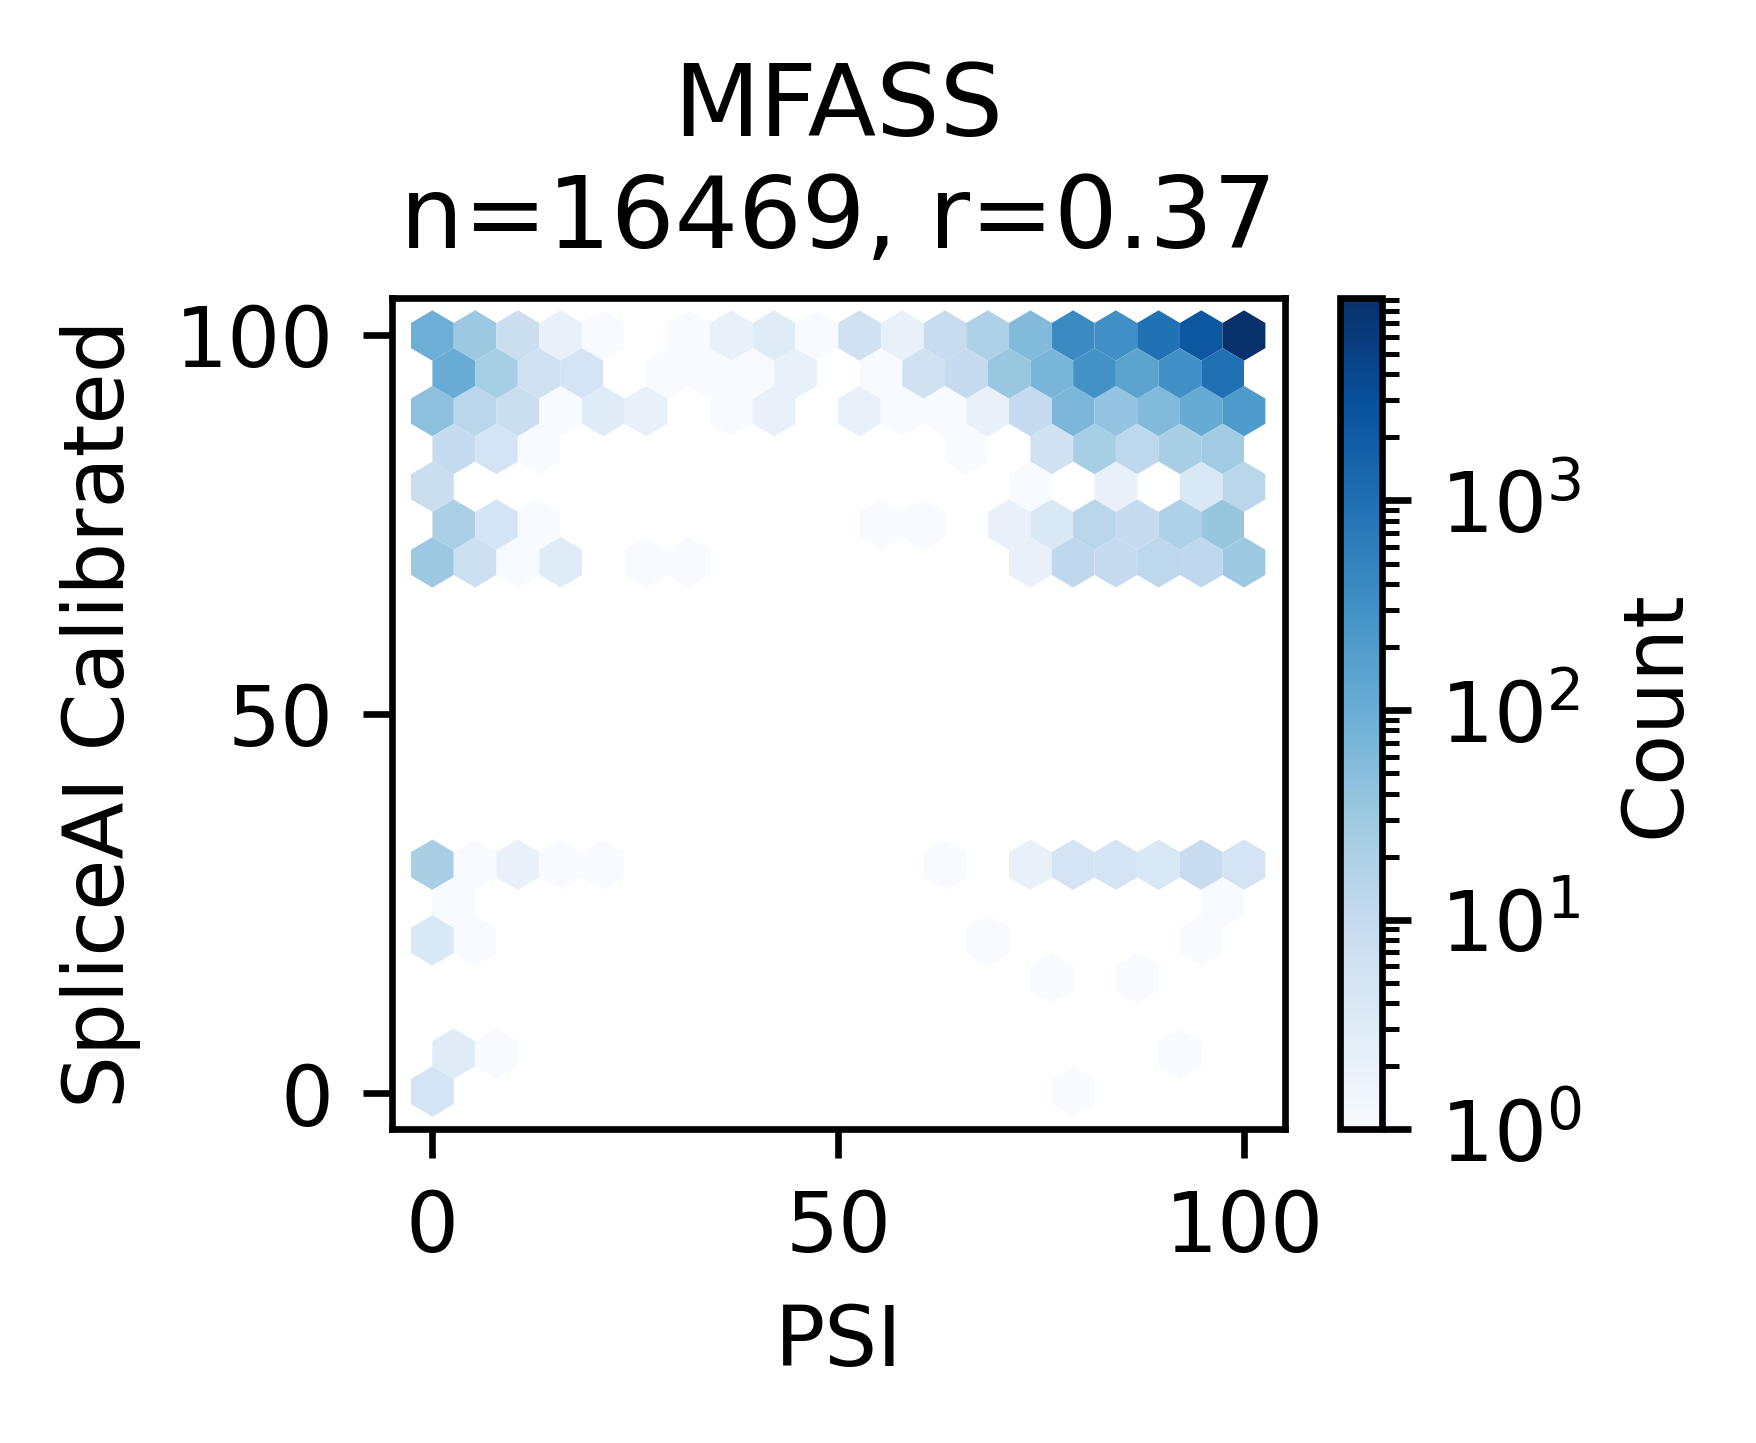

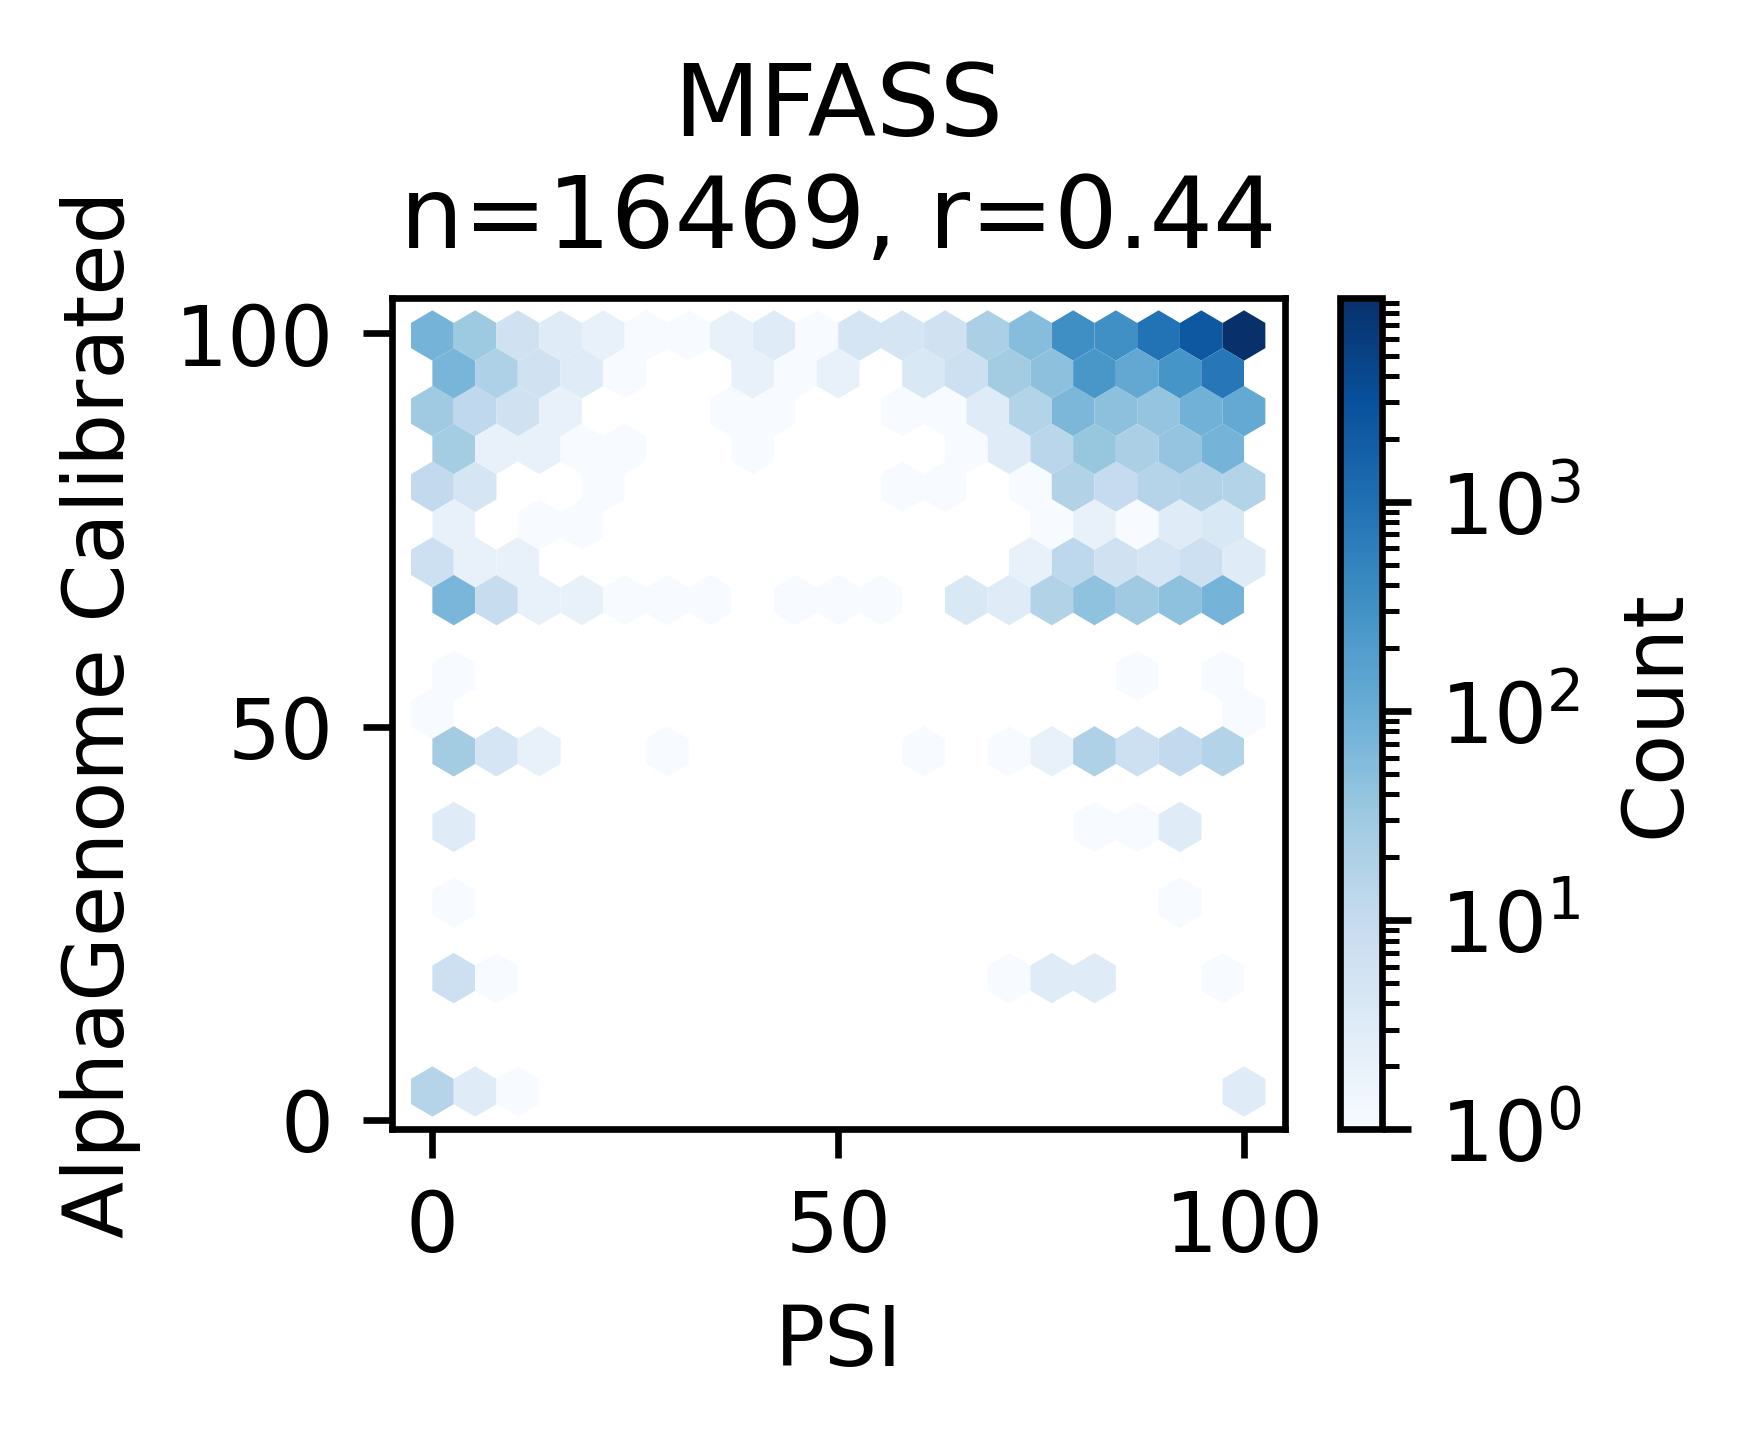

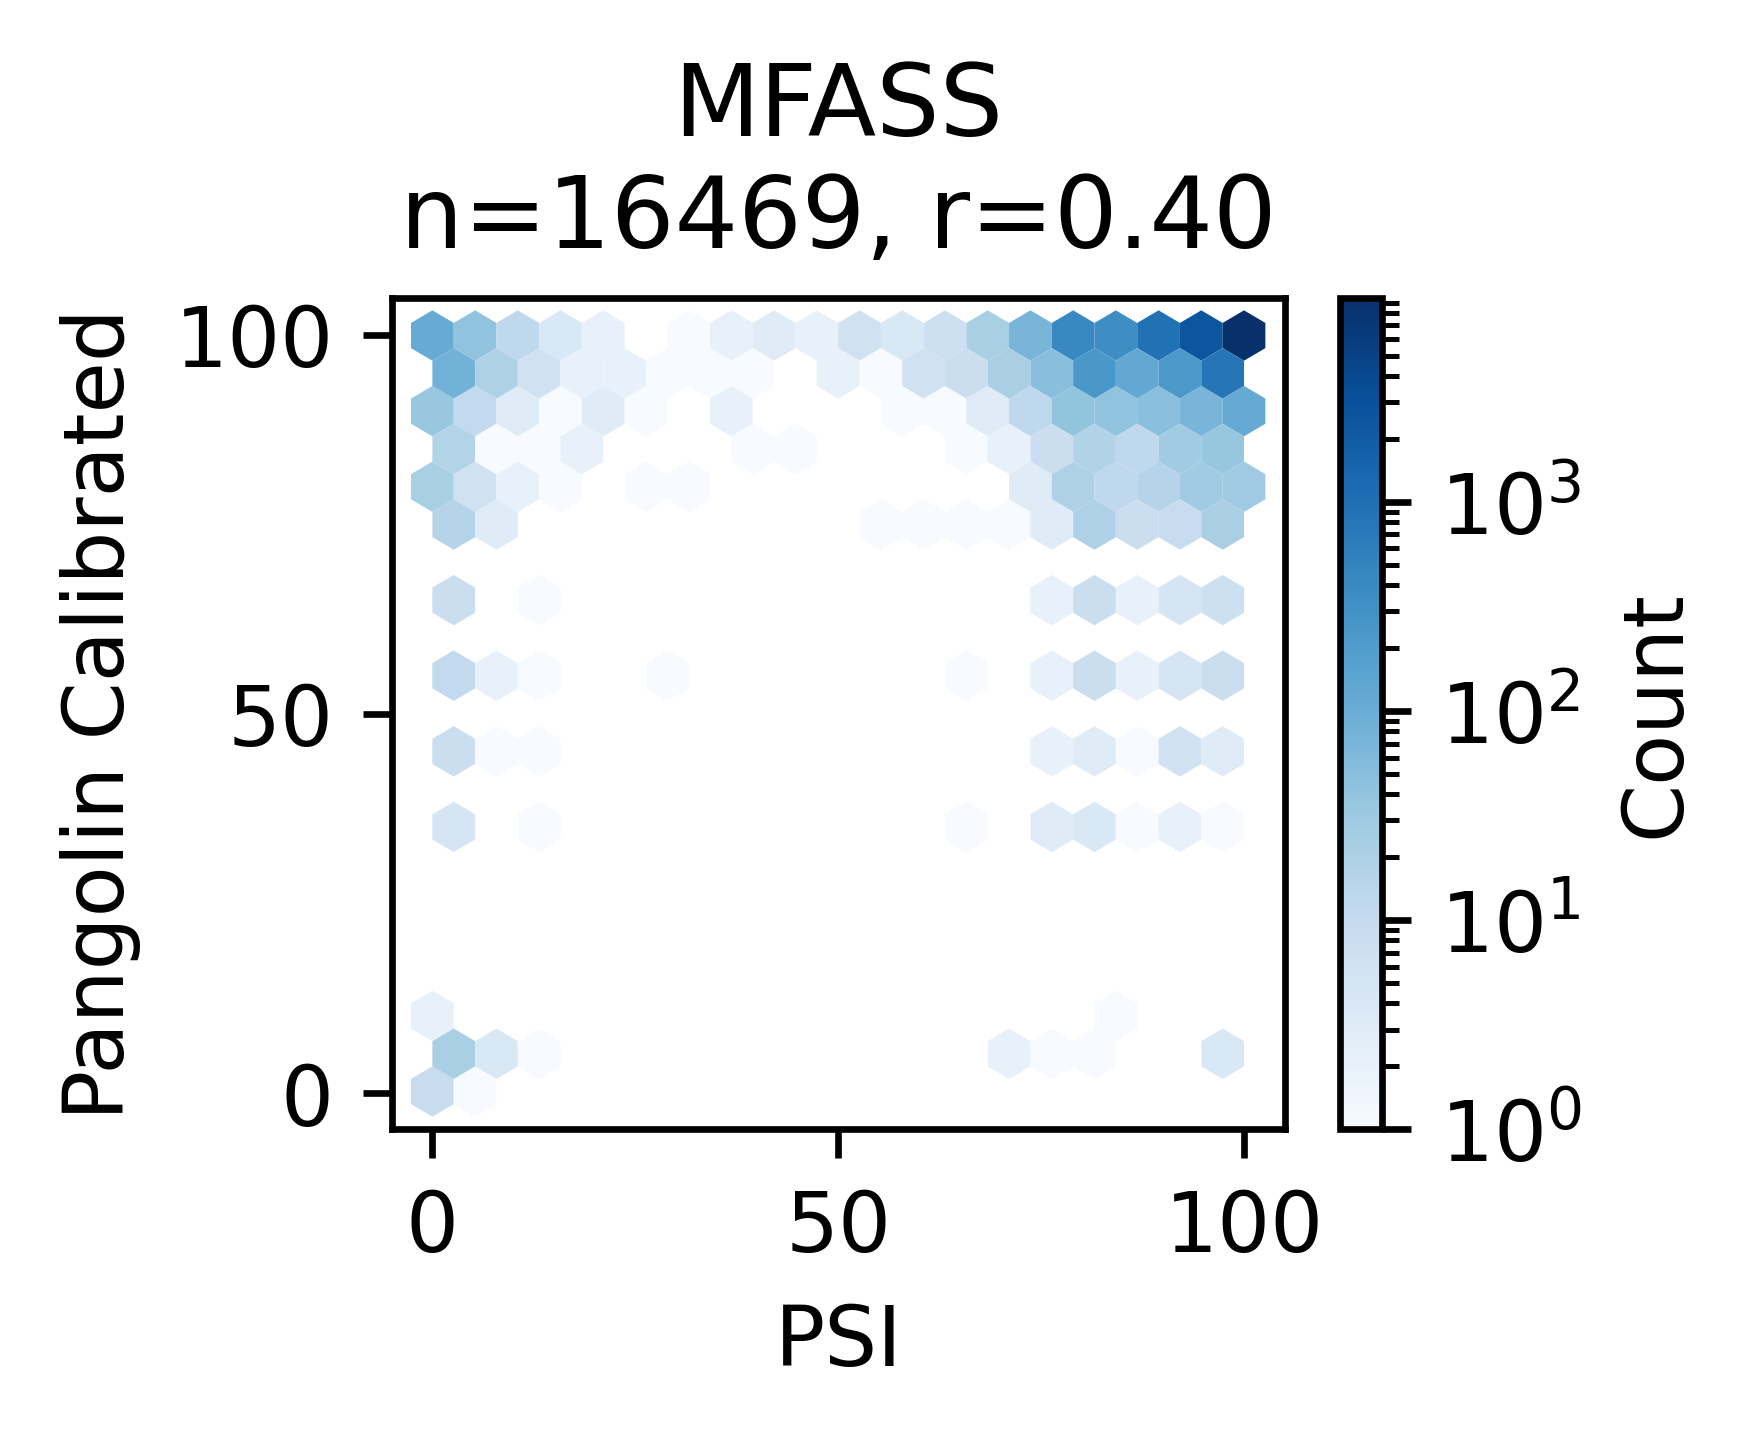

In [7]:
models = [
    ("spliceai_avg", "SpliceAI"), 
    ("alphagenome_junctions_psi", "AlphaGenome"), 
    ("pangolin_average_usage_avg", "Pangolin"),
]

for key, data in assay_data.items():
    for m, m_name in models:
        x = assay_data[key]["PSI"]
        y = scipy.special.expit(
            assay_data[key][f"{m}_logit_calibrated"]
        ) * 100
        fig, ax = plt.subplots(1,1, figsize=(2.4,1.8), dpi=600)
        hb = ax.hexbin(
            x,
            y,
            bins="log",
            cmap="Blues",
            mincnt=1,
            gridsize=19,
            edgecolors='none',
            linewidths=0
        )
        rmse = np.sqrt(np.mean((x - y)**2))
        r = scipy.stats.linregress(x, y).rvalue
        
        fig.colorbar(hb, ax=ax, label="Count")
        
        ax.set_xlabel("PSI")
        ax.set_ylabel(f"{m_name} Calibrated")
        ax.set_title(f"{display_names[key]}\nn={len(x)}, r={r:.2f}")
        
        fig.savefig(f"figures/{key}_{m}_Calibrated_Performance.svg", bbox_inches="tight")

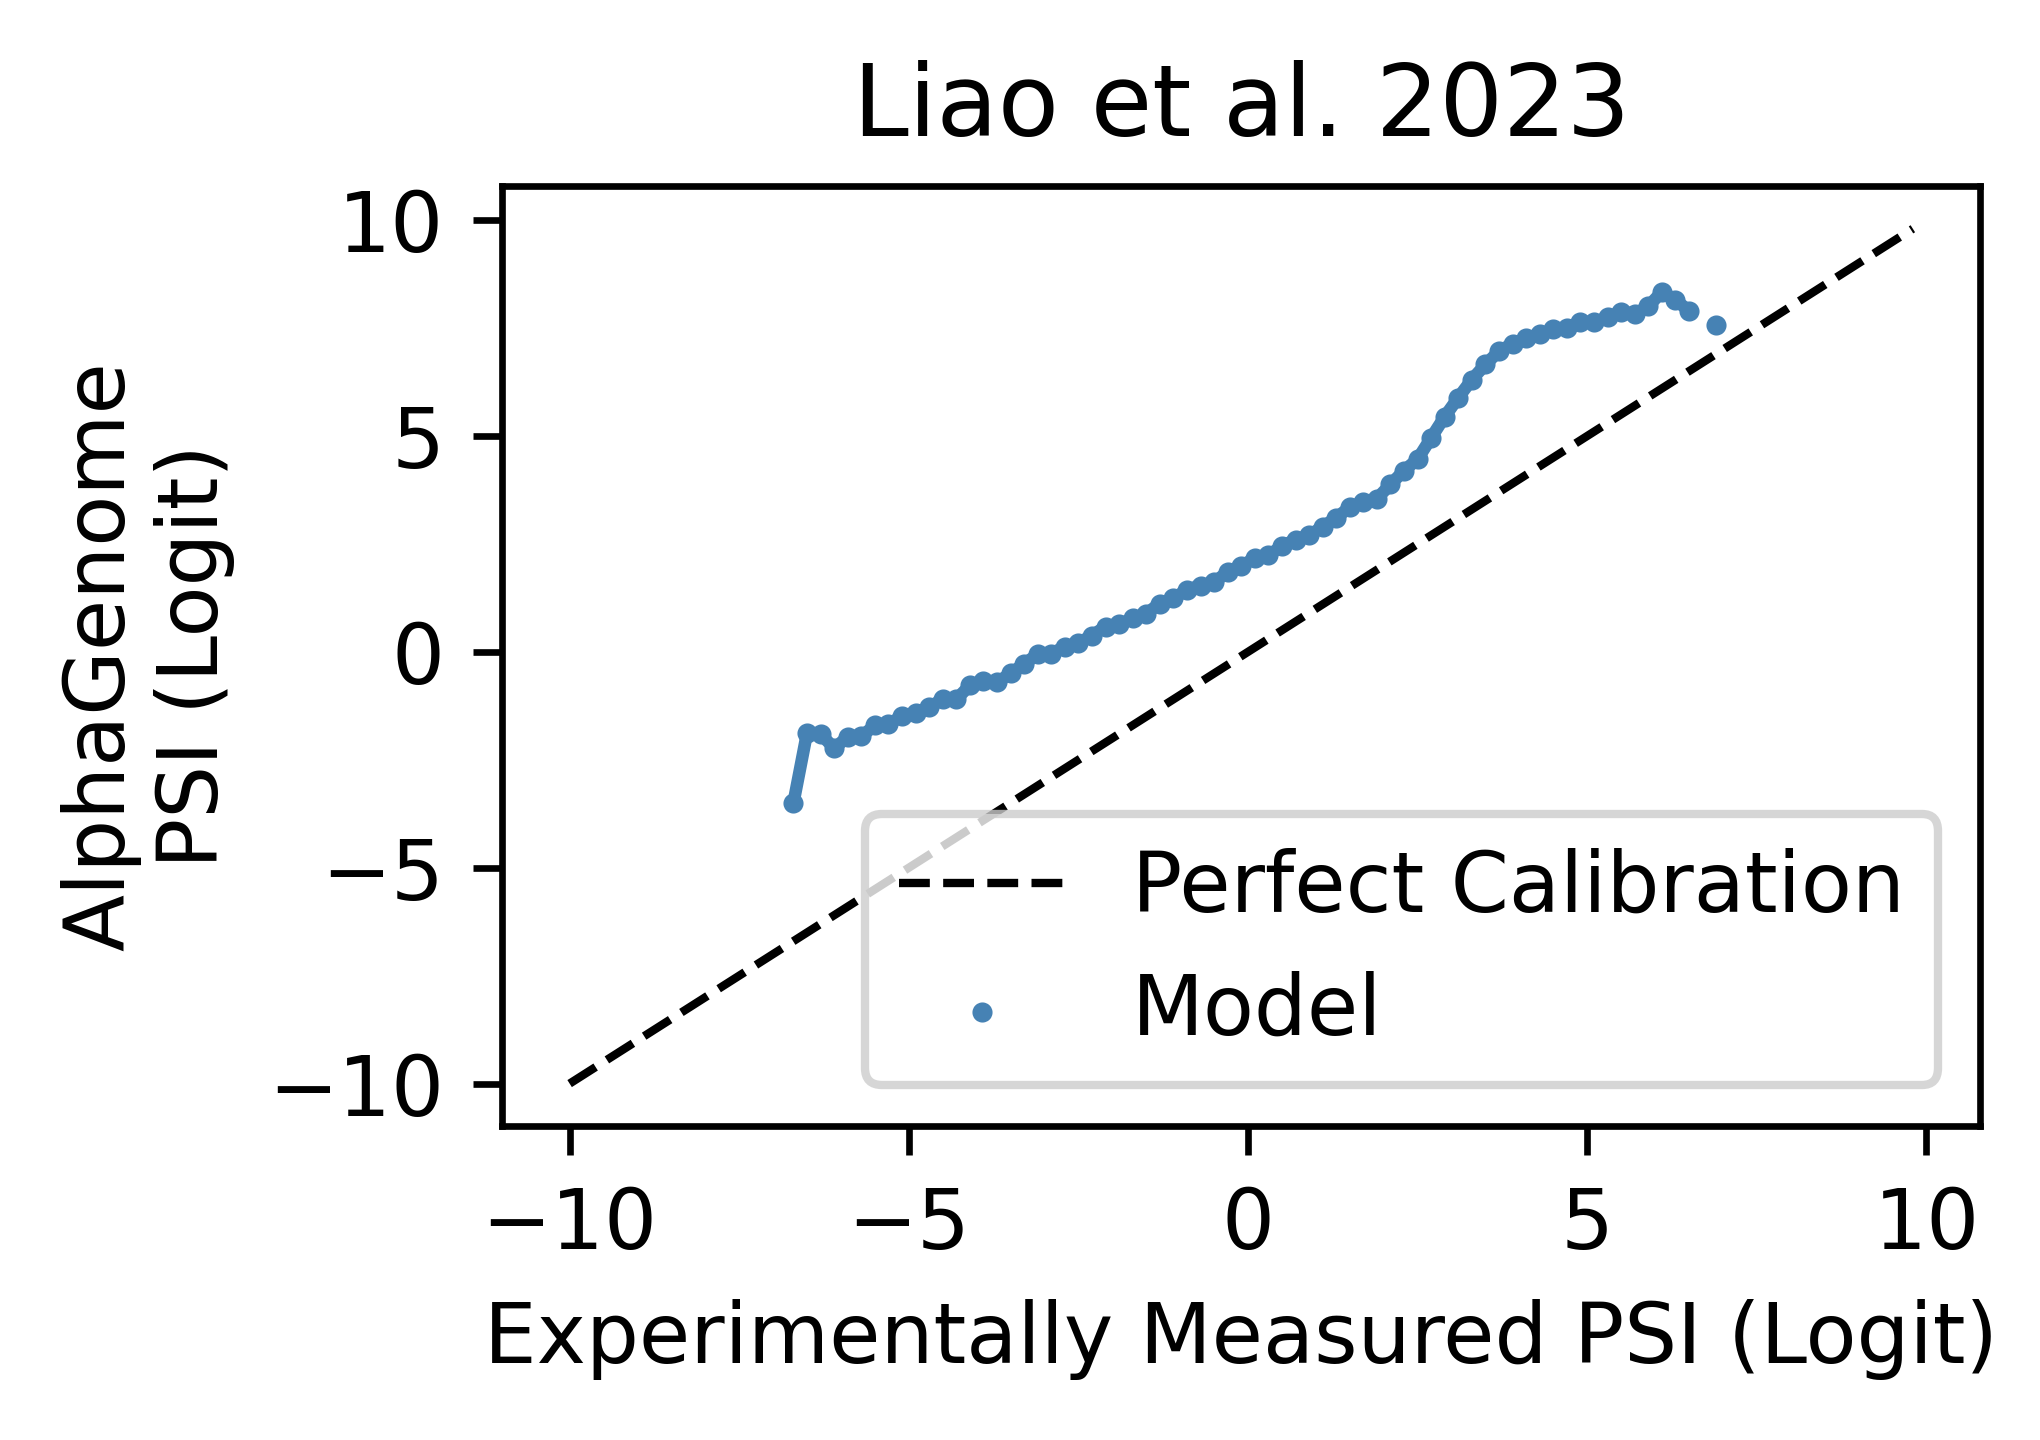

In [8]:
fig, _ = plot_utils.plot_calibration(
    x=assay_data["liao2023"]["PSI_logit_clipped"], 
    y=scipy.special.logit(assay_data["liao2023"]["alphagenome_junctions_psi"]),
    xlabel="Experimentally Measured PSI (Logit)",
    ylabel="AlphaGenome\nPSI (Logit)",
    title="Liao et al. 2023"
)
fig.savefig("figures/Liao2023_AlphaGenome_Reliability_Uncalibrated.svg")

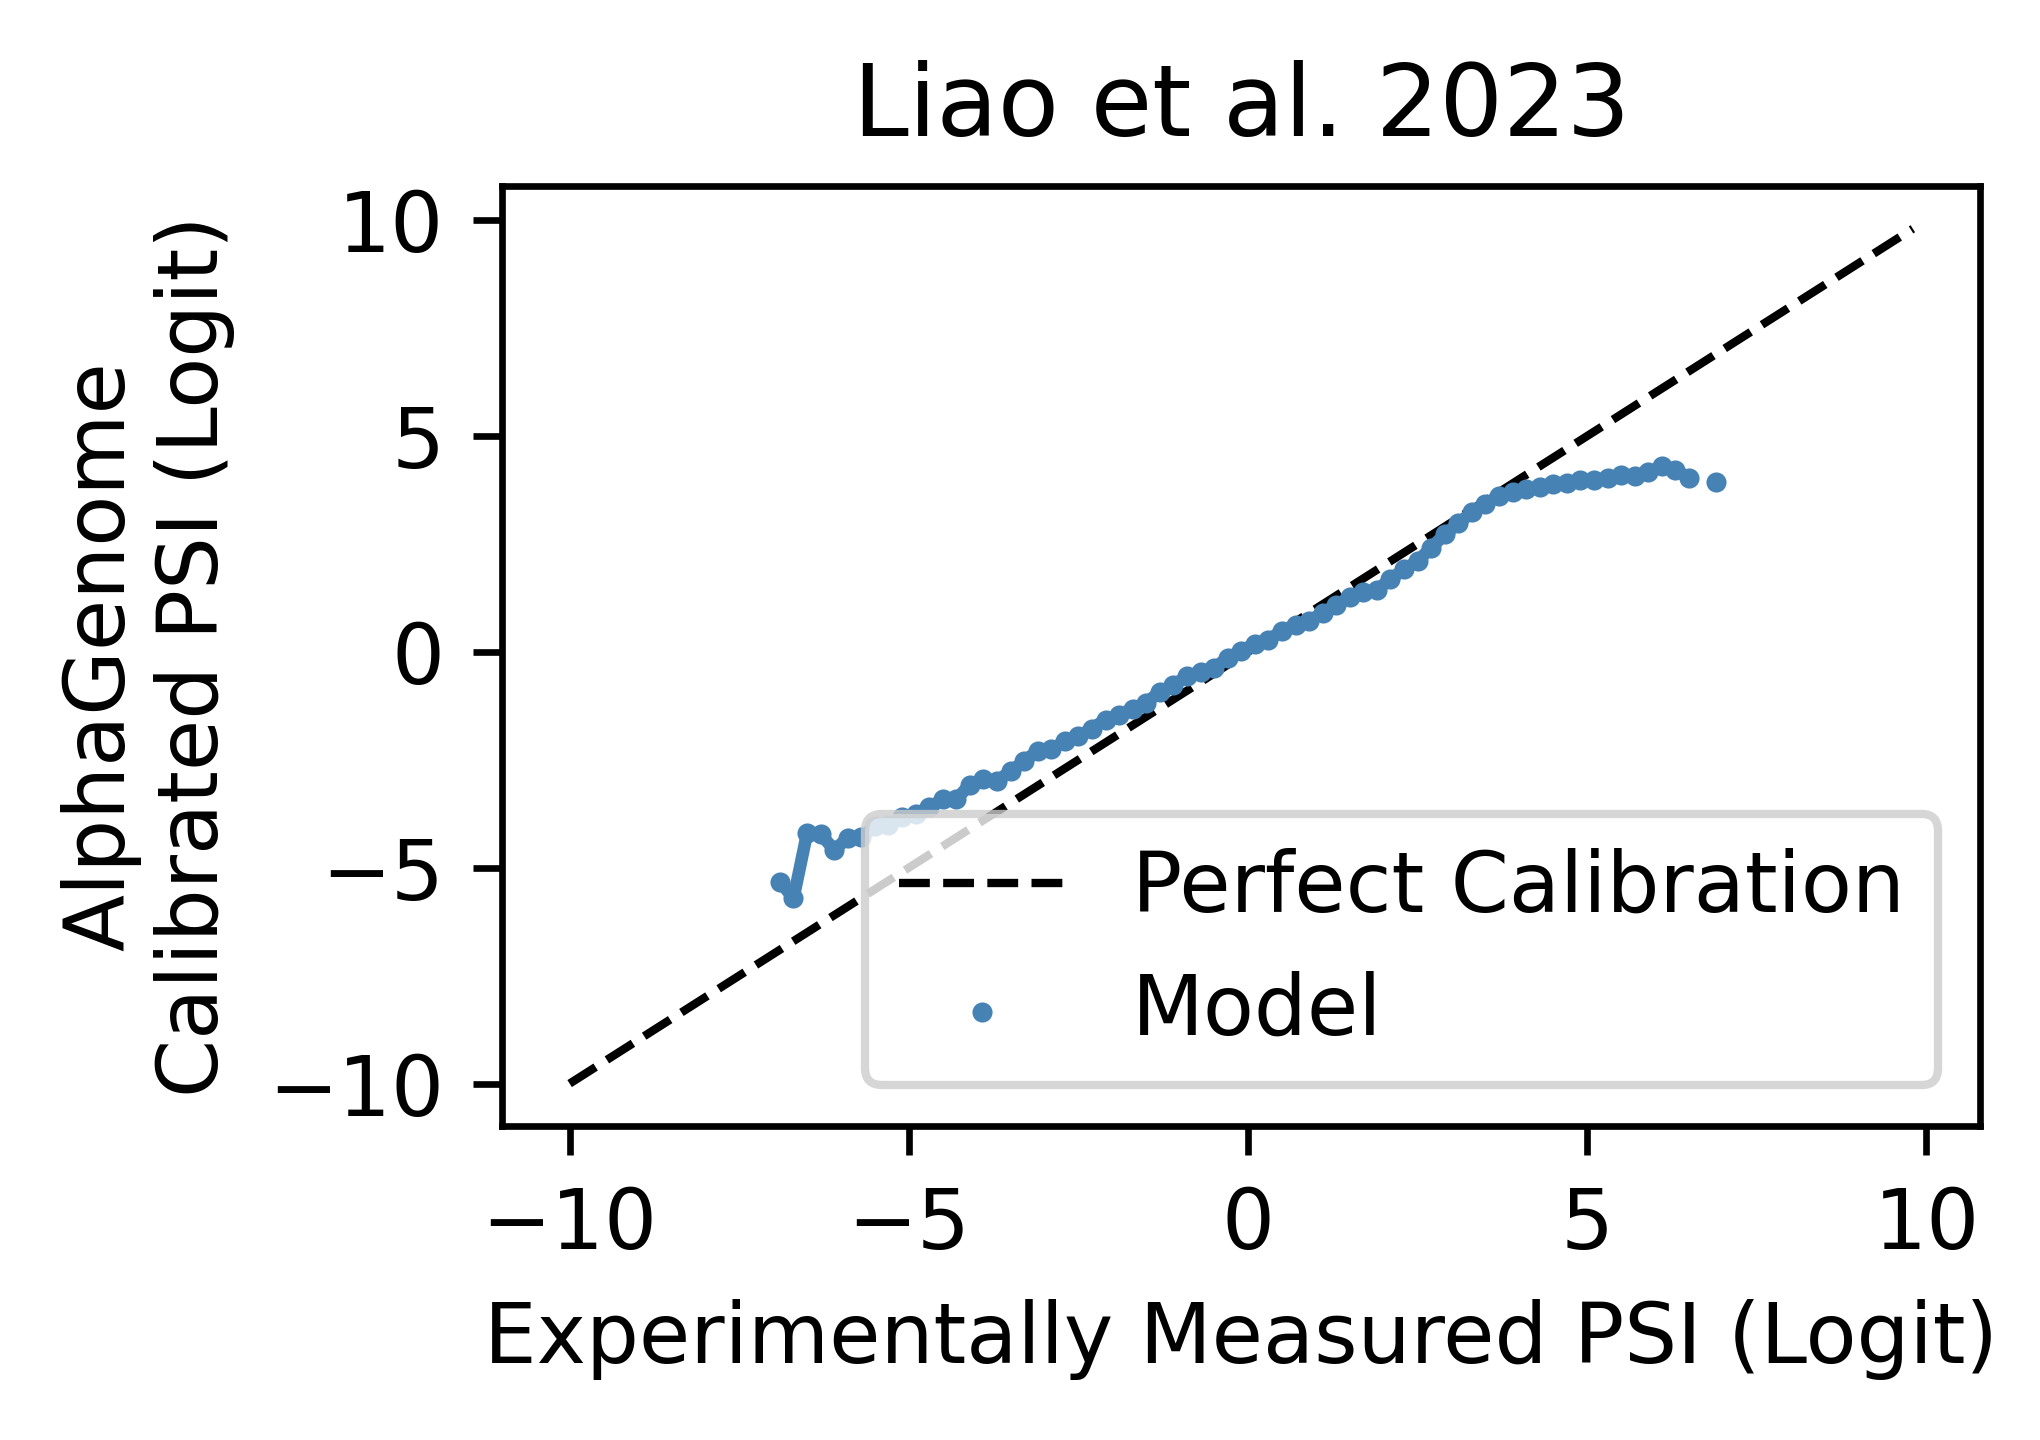

In [9]:
fig, _ = plot_utils.plot_calibration(
    x=assay_data["liao2023"]["PSI_logit_clipped"], 
    y=(
        assay_data["liao2023"]["alphagenome_junctions_psi_logit_calibrated"]
    ),
    xlabel="Experimentally Measured PSI (Logit)",
    ylabel="AlphaGenome\nCalibrated PSI (Logit)", 
    title="Liao et al. 2023"
)
fig.savefig("figures/Liao2023_AlphaGenome_Reliability_Calibrated.svg")

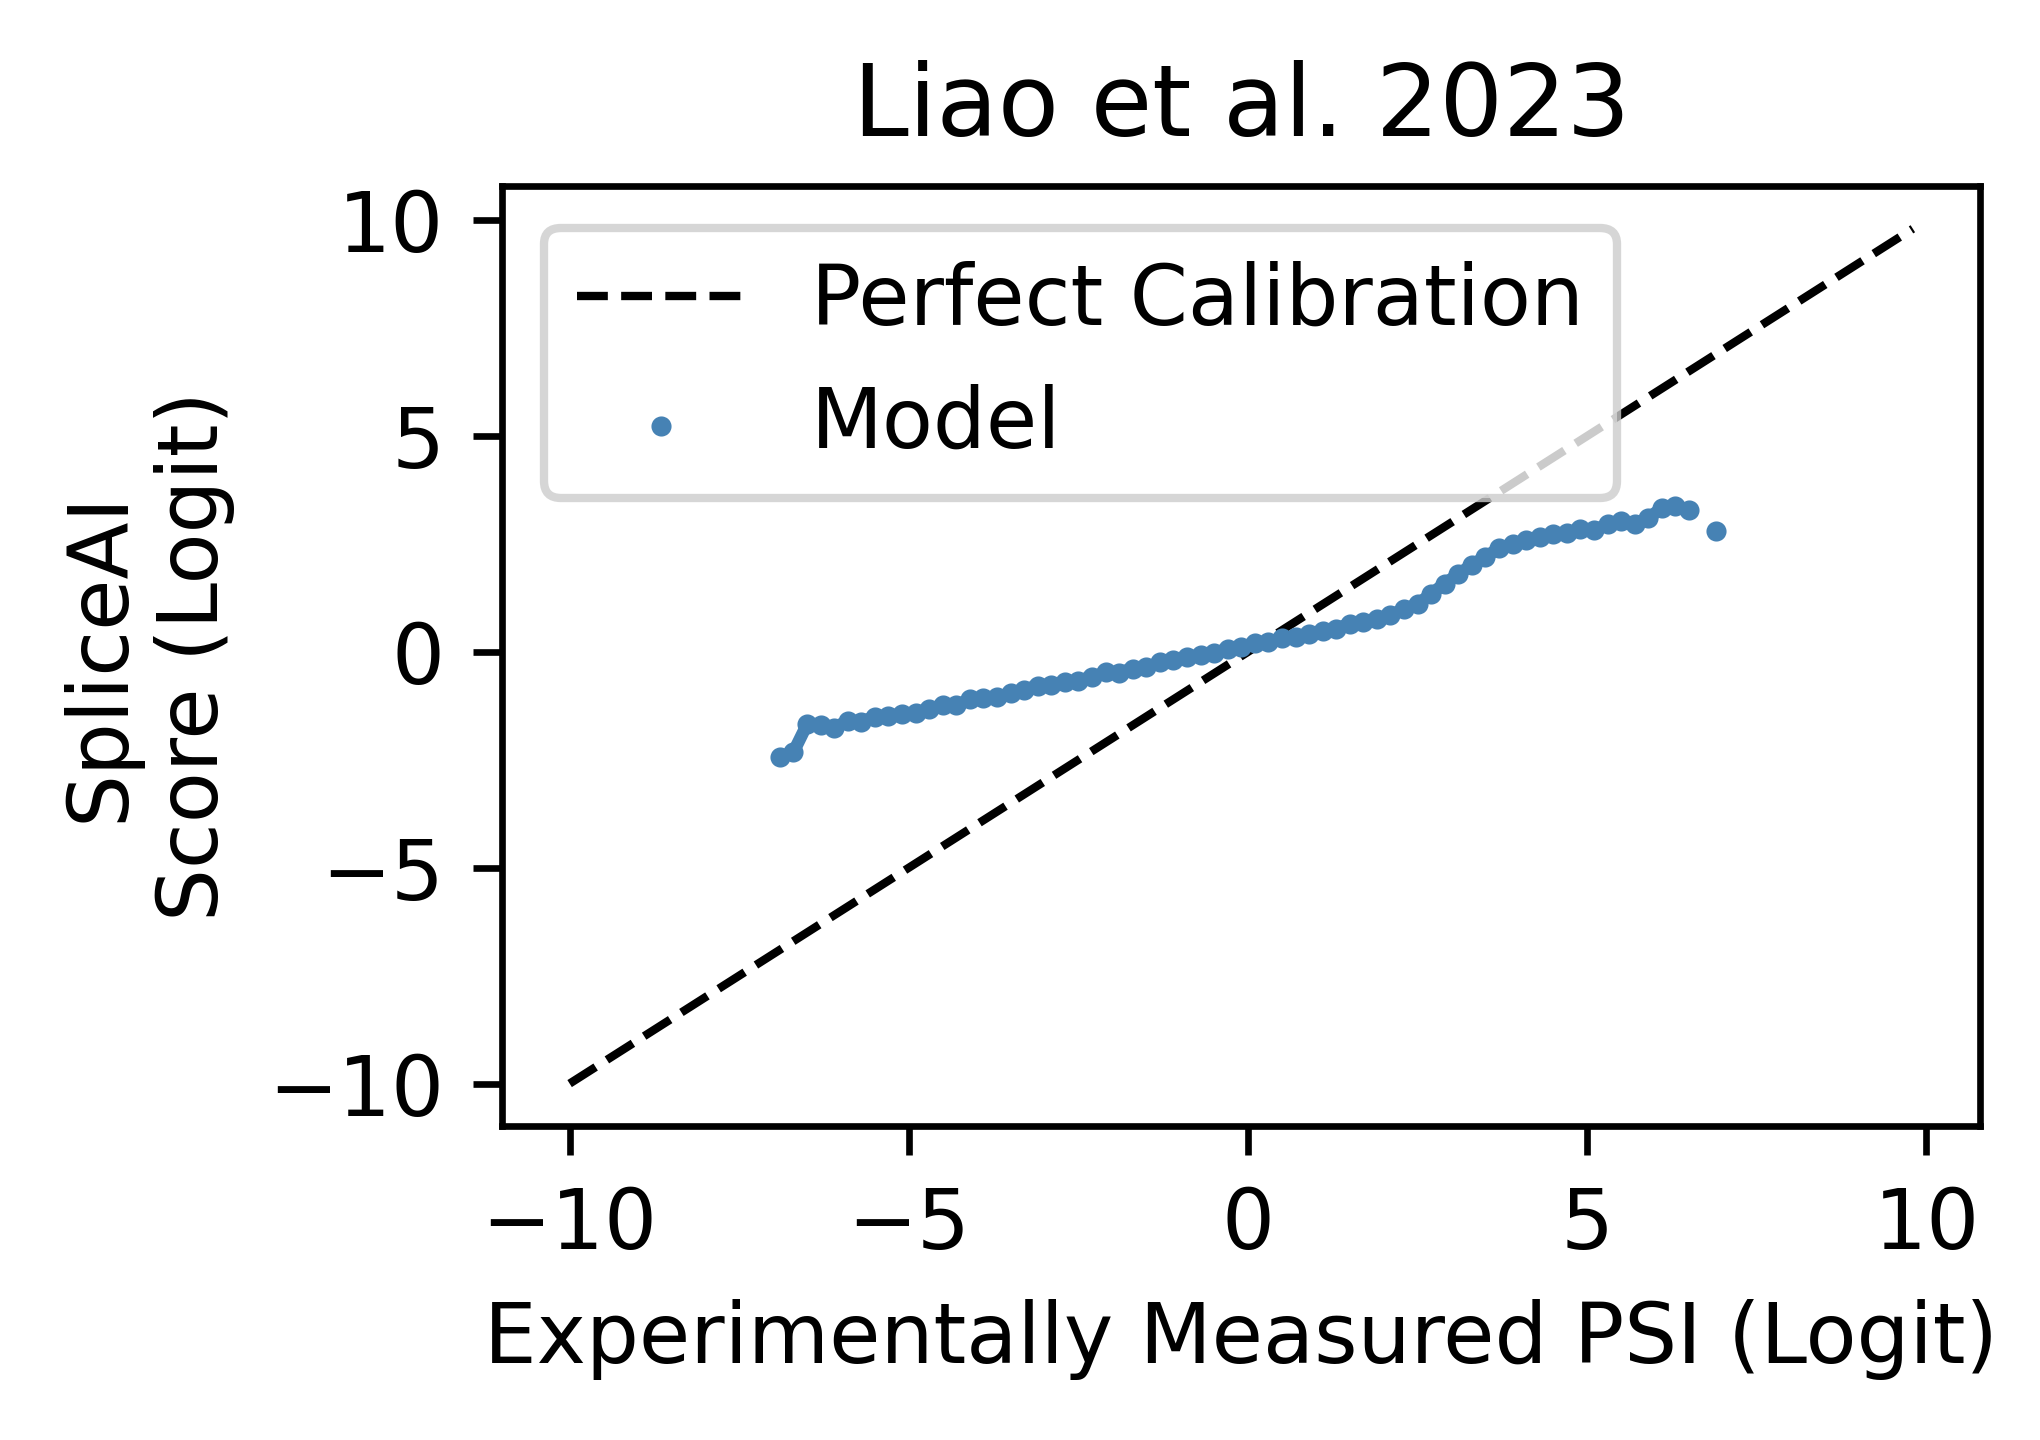

In [10]:
fig, _ = plot_utils.plot_calibration(
    x=assay_data["liao2023"]["PSI_logit_clipped"], 
    y=scipy.special.logit(assay_data["liao2023"]["spliceai_avg"]),
    xlabel="Experimentally Measured PSI (Logit)",
    ylabel="SpliceAI\nScore (Logit)",
    title="Liao et al. 2023"
)
fig.savefig("figures/Liao2023_SpliceAI_Reliability_Uncalibrated.svg")

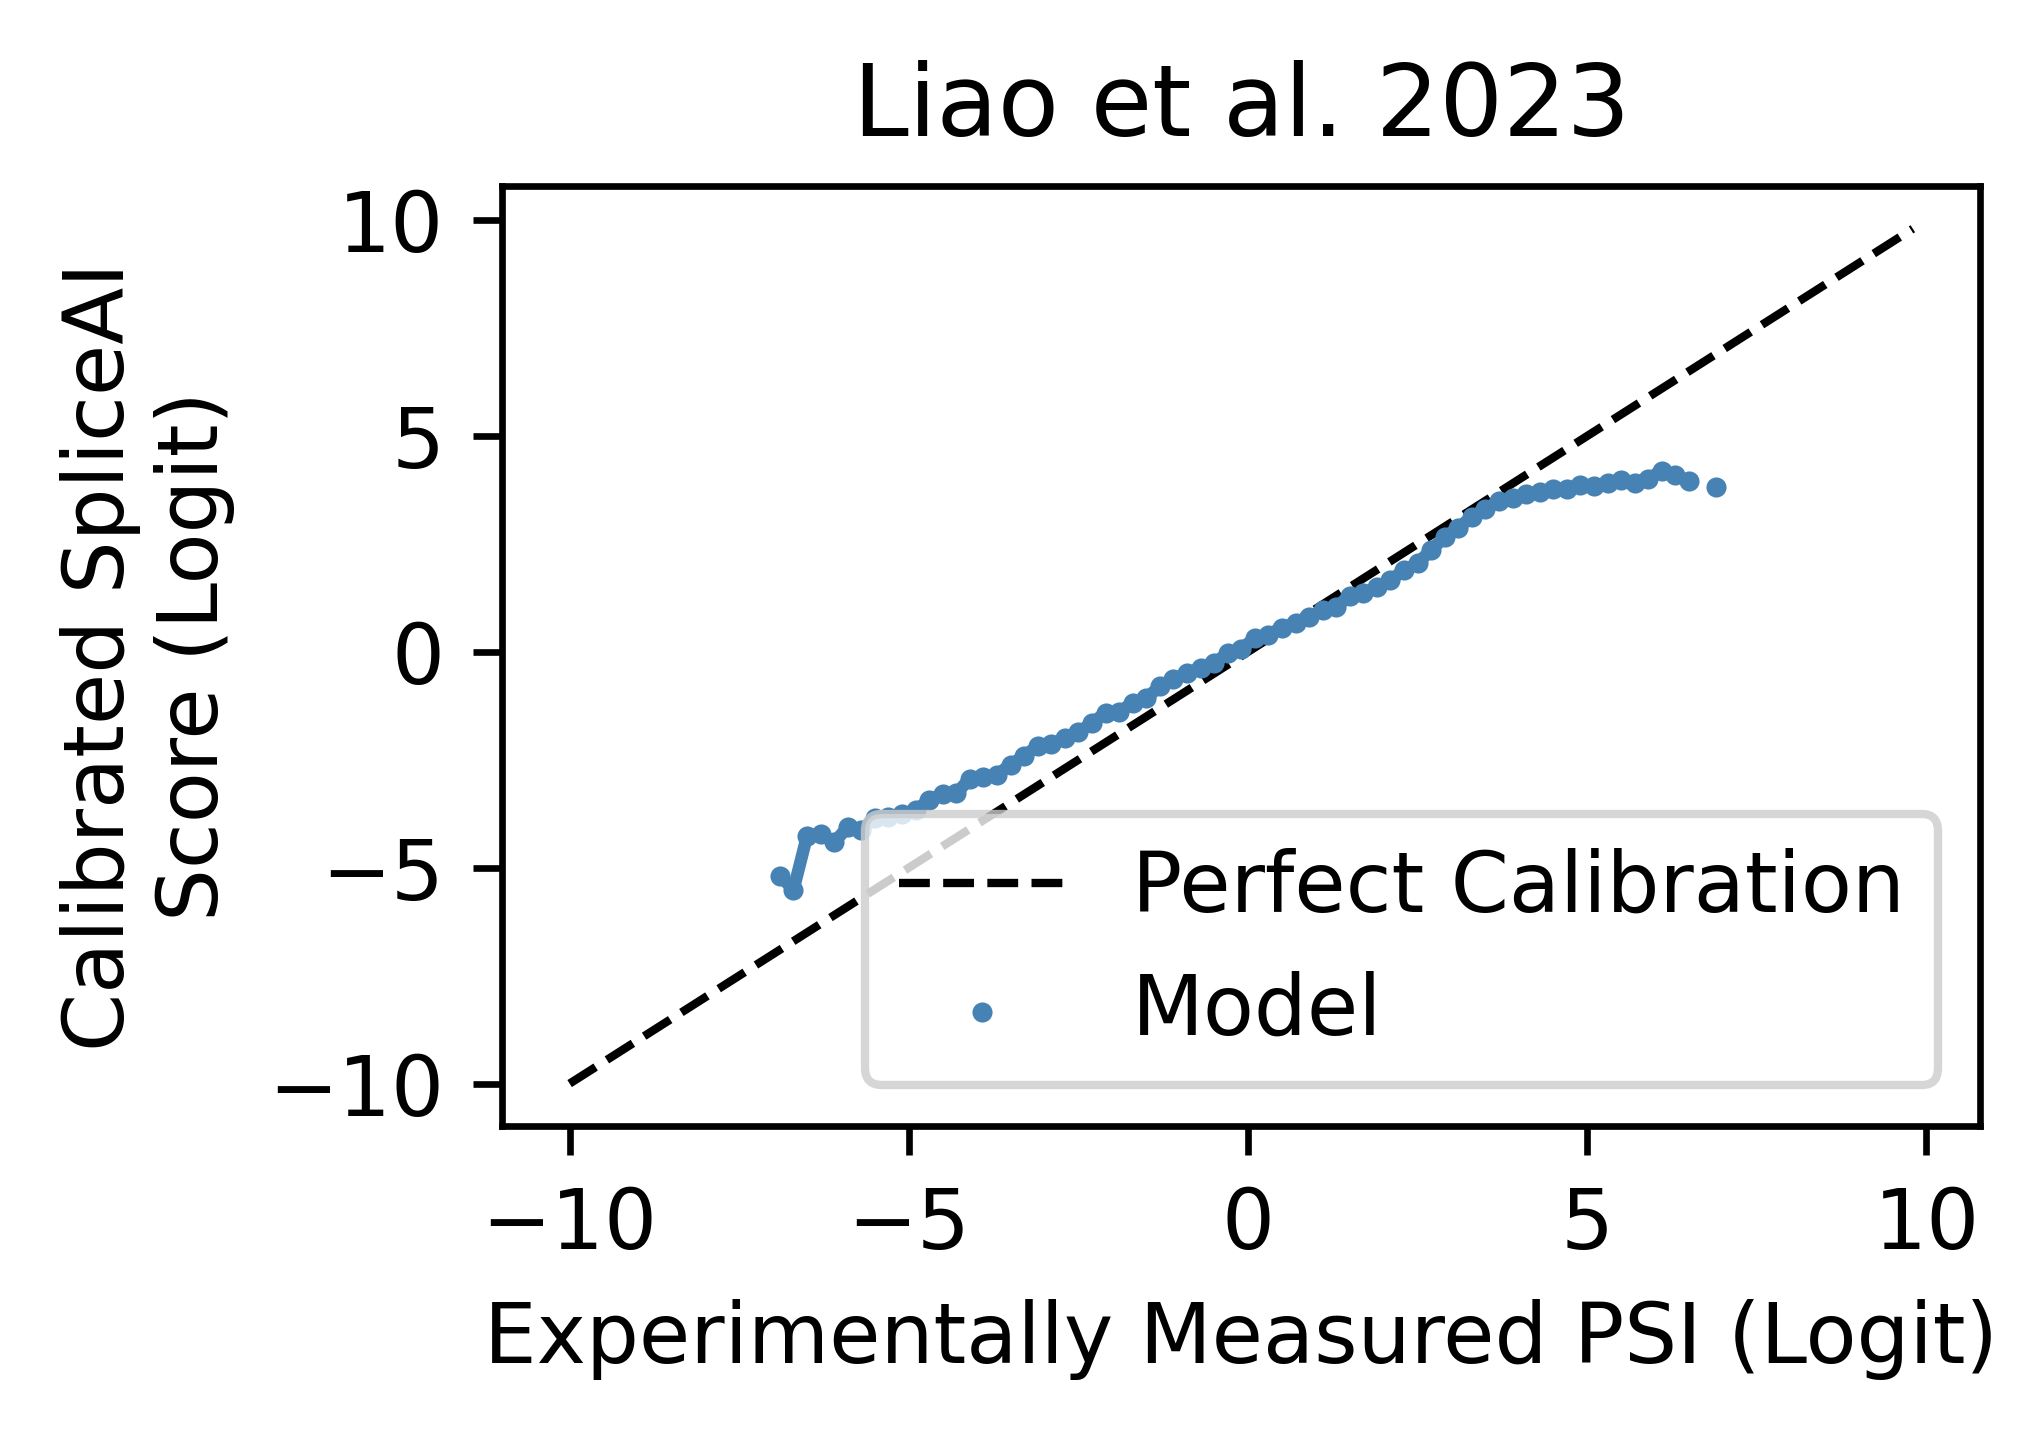

In [11]:
fig, _ = plot_utils.plot_calibration(
    x=assay_data["liao2023"]["PSI_logit_clipped"], 
    y=(
        assay_data["liao2023"]["spliceai_avg_logit_calibrated"]
    ),
    xlabel="Experimentally Measured PSI (Logit)",
    ylabel="Calibrated SpliceAI\nScore (Logit)", 
    title="Liao et al. 2023"
)
fig.savefig("figures/Liao2023_SpliceAI_Reliability_Calibrated.svg")

## 4. Add CpG and stop codon metadata

In [12]:
for key, data in assay_data.items():
    assay_data[key] = seq_utils.add_CpG_features(assay_data[key], sequence_col="exon")
    assay_data[key] = seq_utils.add_stop_codon_features(assay_data[key], sequence_col="exon")

In [13]:
# Discretize CpG and GpC obs/exp ratios
for key, data in assay_data.items():
    for dinuc in ["CpG", "GpC"]:    
        assay_data[key][f"{dinuc}_obs_exp_disc"] = plot_utils.discretize_variable(
            assay_data[key][f"{dinuc}_obs_exp"], 
            0.25,
            min_val=None, 
            max_val=1.75,
            labels=True,
            include_above_max=True,
            label_precision=3,
        )
        assay_data[key][f"{dinuc}_obs_exp_disc"] = plot_utils.discretize_variable(
            assay_data[key][f"{dinuc}_obs_exp"], 
            0.25,
            min_val=None, 
            max_val=1.75,
            labels=True,
            include_above_max=True,
            label_precision=3,
        )

In [14]:
for key, data in assay_data.items():
    print(key, len(data))

liao2023 239772
baeza-centurion2025 5976
chong2019 16469


## 5. Add model errors

In [15]:
error_cols = [
    ("spliceai_avg_calibrated_error", "spliceai_avg_logit_calibrated"),
    ("alphagenome_junctions_psi_calibrated_error", "alphagenome_junctions_psi_logit_calibrated"),
    ("pangolin_average_usage_avg_calibrated_error", "pangolin_average_usage_avg_logit_calibrated"),
]
for key, data in assay_data.items():
    for error_col, pred_col in error_cols:
        assay_data[key][error_col] = \
            scipy.special.expit(
                assay_data[key][pred_col]
            ) * 100 - assay_data[key]["PSI"]

In [16]:
model_error_cols = {    
    "spliceai_avg_calibrated_error": "SpliceAI",
    "pangolin_average_usage_avg_calibrated_error": "Pangolin",
    "alphagenome_junctions_psi_calibrated_error": "AlphaGenome"
}

## 6. CpG Bias

In [17]:
bbox_to_anchors = {
    "liao2023" : (0.5, -0.55),
    "baeza-centurion2025": (0.5, -0.50),
    "chong2019": (0.5, -0.62),
}

ceiling_counts = {
    "liao2023" : 8,
    "baeza-centurion2025": 10,
    "chong2019": 8,
}

target_bins = {
    "liao2023" : 5,
    "baeza-centurion2025": 5,
    "chong2019": 10,
}

figsizes = {
    # "liao2023" : (5.8, 3.25),
    # "baeza-centurion2025": (5.8, 3.25),
    # "chong2019": (5.8, 3.25),
    "liao2023" : (2.8, 2.25),
    "baeza-centurion2025": (2.8, 2.25),
    "chong2019": (2.8, 2.25),
}

#fontsize = 10
fontsize = 8

In [18]:
group_col = {
    "liao2023" : "CpG_obs_exp_disc",
    "baeza-centurion2025": "CpG_obs",
    "chong2019": "CpG_obs_exp_disc",
}

group_continuous_col = {
    "liao2023" : "CpG_obs_exp",
    "baeza-centurion2025": "CpG_obs",
    "chong2019": "CpG_obs_exp",
}

group_label = {
    "liao2023" : "CpG Ratio",
    "baeza-centurion2025": "Number of CpG",
    "chong2019": "CpG Ratio",
}

for key, data in assay_data.items():
    for model_col, model_name in model_error_cols.items():
        pred_label = "Model Error (Score - PSI)"
        if "calibrated" in model_col:
            pred_label = "Model Error (Calibrated Score - PSI)"
        fig = plot_utils.plot_grouped_violin_analysis(
            data,
            predictor_col=model_col,
            target_col="PSI",
            group_col=group_col[key],
            predictor_label=pred_label,
            target_label="Experimentally Measured PSI",
            group_label=group_label[key],
            target_bins=target_bins[key],
            ceiling_count=ceiling_counts[key],
            min_samples=20,
            title=f"{display_names[key]}, {model_name}",
            cmap='inferno',
            ylim=(-105, 105),
            legend=True,
            legend_loc="lower center",
            legend_ncols=8,
            bbox_to_anchor=bbox_to_anchors[key],
            dpi=600,
            figsize=figsizes[key],
            fontsize_title=fontsize,
            fontsize_axis_labels=fontsize,
            fontsize_xtick=fontsize,
            fontsize_ytick=fontsize,
            fontsize_legend=fontsize,
            fontsize_sample_counts=5,
            numeric_binning=False,
            legend_row_major=True
        )
        fig.show()
        fig.savefig(f"figures/{key}_{model_col}_CpG_Error.svg", bbox_inches='tight')
        plt.close()
                
        model = smf.ols(f"{model_col} ~ {group_continuous_col[key]} + PSI", data=data).fit()
        print(key, model_name, model.summary())

/var/folders/vg/d_4ndfrn7615qk6kxwxnqdl80000gn/T/ipykernel_61899/161161077.py:53: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


liao2023 SpliceAI                                   OLS Regression Results                                 
Dep. Variable:     spliceai_avg_calibrated_error   R-squared:                       0.149
Model:                                       OLS   Adj. R-squared:                  0.149
Method:                            Least Squares   F-statistic:                 2.101e+04
Date:                           Sun, 17 May 2026   Prob (F-statistic):               0.00
Time:                                   22:53:57   Log-Likelihood:            -1.0780e+06
No. Observations:                         239772   AIC:                         2.156e+06
Df Residuals:                             239769   BIC:                         2.156e+06
Df Model:                                      2                                         
Covariance Type:                       nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
--

/var/folders/vg/d_4ndfrn7615qk6kxwxnqdl80000gn/T/ipykernel_61899/161161077.py:53: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


liao2023 Pangolin                                          OLS Regression Results                                        
Dep. Variable:     pangolin_average_usage_avg_calibrated_error   R-squared:                       0.151
Model:                                                     OLS   Adj. R-squared:                  0.151
Method:                                          Least Squares   F-statistic:                 2.131e+04
Date:                                         Sun, 17 May 2026   Prob (F-statistic):               0.00
Time:                                                 22:53:58   Log-Likelihood:            -1.0887e+06
No. Observations:                                       239772   AIC:                         2.177e+06
Df Residuals:                                           239769   BIC:                         2.177e+06
Df Model:                                                    2                                         
Covariance Type:                              

/var/folders/vg/d_4ndfrn7615qk6kxwxnqdl80000gn/T/ipykernel_61899/161161077.py:53: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
/var/folders/vg/d_4ndfrn7615qk6kxwxnqdl80000gn/T/ipykernel_61899/161161077.py:53: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


...

/var/folders/vg/d_4ndfrn7615qk6kxwxnqdl80000gn/T/ipykernel_61899/161161077.py:53: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
/var/folders/vg/d_4ndfrn7615qk6kxwxnqdl80000gn/T/ipykernel_61899/161161077.py:53: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


baeza-centurion2025 Pangolin                                          OLS Regression Results                                        
Dep. Variable:     pangolin_average_usage_avg_calibrated_error   R-squared:                       0.145
Model:                                                     OLS   Adj. R-squared:                  0.144
Method:                                          Least Squares   F-statistic:                     505.2
Date:                                         Sun, 17 May 2026   Prob (F-statistic):          2.00e-203
Time:                                                 22:53:59   Log-Likelihood:                -25588.
No. Observations:                                         5976   AIC:                         5.118e+04
Df Residuals:                                             5973   BIC:                         5.120e+04
Df Model:                                                    2                                         
Covariance Type:                   

/var/folders/vg/d_4ndfrn7615qk6kxwxnqdl80000gn/T/ipykernel_61899/161161077.py:53: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
/var/folders/vg/d_4ndfrn7615qk6kxwxnqdl80000gn/T/ipykernel_61899/161161077.py:53: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


chong2019 SpliceAI                                   OLS Regression Results                                 
Dep. Variable:     spliceai_avg_calibrated_error   R-squared:                       0.859
Model:                                       OLS   Adj. R-squared:                  0.859
Method:                            Least Squares   F-statistic:                 5.002e+04
Date:                           Sun, 17 May 2026   Prob (F-statistic):               0.00
Time:                                   22:53:59   Log-Likelihood:                -52699.
No. Observations:                          16469   AIC:                         1.054e+05
Df Residuals:                              16466   BIC:                         1.054e+05
Df Model:                                      2                                         
Covariance Type:                       nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-

/var/folders/vg/d_4ndfrn7615qk6kxwxnqdl80000gn/T/ipykernel_61899/161161077.py:53: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


### GpC Control

In [19]:
group_col = {
    "liao2023" : "GpC_obs_exp_disc",
    "baeza-centurion2025": "GpC_obs",
    "chong2019": "GpC_obs_exp_disc",
}

group_continuous_col = {
    "liao2023" : "GpC_obs_exp",
    "baeza-centurion2025": "GpC_obs",
    "chong2019": "GpC_obs_exp",
}

group_label = {
    "liao2023" : "GpC Ratio",
    "baeza-centurion2025": "Number of GpC",
    "chong2019": "GpC Ratio",
}

for key, data in assay_data.items():
    for model_col, model_name in model_error_cols.items():
        pred_label = "Model Error (Score - PSI)"
        if "calibrated" in model_col:
            pred_label = "Model Error (Calibrated Score - PSI)"
        fig = plot_utils.plot_grouped_violin_analysis(
            data,
            predictor_col=model_col,
            target_col="PSI",
            group_col=group_col[key],
            predictor_label=pred_label,
            target_label="Experimentally Measured PSI",
            group_label=group_label[key],
            target_bins=target_bins[key],
            ceiling_count=ceiling_counts[key],
            min_samples=20,
            title=f"{display_names[key]}, {model_name}",
            cmap='inferno',
            ylim=(-105, 105),
            legend=True,
            legend_loc="lower center",
            legend_ncols=8,
            bbox_to_anchor=bbox_to_anchors[key],
            dpi=600,
            figsize=figsizes[key],
            fontsize_title=fontsize,
            fontsize_axis_labels=fontsize,
            fontsize_xtick=fontsize,
            fontsize_ytick=fontsize,
            fontsize_legend=fontsize,
            fontsize_sample_counts=5,
            numeric_binning=(key == "baeza-centurion2025"),
            numeric_bin_size=1,
            legend_row_major=True
        )
        fig.show()
        fig.savefig(f"figures/{key}_{model_col}_GpC_Error.svg", bbox_inches='tight')
        plt.close()

        model = smf.ols(f"{model_col} ~ {group_continuous_col[key]} + PSI", data=data).fit()
        print(key, model_name, model.summary())

/var/folders/vg/d_4ndfrn7615qk6kxwxnqdl80000gn/T/ipykernel_61899/2152824178.py:54: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


liao2023 SpliceAI                                   OLS Regression Results                                 
Dep. Variable:     spliceai_avg_calibrated_error   R-squared:                       0.104
Model:                                       OLS   Adj. R-squared:                  0.104
Method:                            Least Squares   F-statistic:                 1.386e+04
Date:                           Sun, 17 May 2026   Prob (F-statistic):               0.00
Time:                                   22:54:00   Log-Likelihood:            -1.0843e+06
No. Observations:                         239772   AIC:                         2.169e+06
Df Residuals:                             239769   BIC:                         2.169e+06
Df Model:                                      2                                         
Covariance Type:                       nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
--

/var/folders/vg/d_4ndfrn7615qk6kxwxnqdl80000gn/T/ipykernel_61899/2152824178.py:54: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


liao2023 Pangolin                                          OLS Regression Results                                        
Dep. Variable:     pangolin_average_usage_avg_calibrated_error   R-squared:                       0.120
Model:                                                     OLS   Adj. R-squared:                  0.120
Method:                                          Least Squares   F-statistic:                 1.628e+04
Date:                                         Sun, 17 May 2026   Prob (F-statistic):               0.00
Time:                                                 22:54:01   Log-Likelihood:            -1.0930e+06
No. Observations:                                       239772   AIC:                         2.186e+06
Df Residuals:                                           239769   BIC:                         2.186e+06
Df Model:                                                    2                                         
Covariance Type:                              

/var/folders/vg/d_4ndfrn7615qk6kxwxnqdl80000gn/T/ipykernel_61899/2152824178.py:54: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
/var/folders/vg/d_4ndfrn7615qk6kxwxnqdl80000gn/T/ipykernel_61899/2152824178.py:54: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


...

/var/folders/vg/d_4ndfrn7615qk6kxwxnqdl80000gn/T/ipykernel_61899/2152824178.py:54: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
/var/folders/vg/d_4ndfrn7615qk6kxwxnqdl80000gn/T/ipykernel_61899/2152824178.py:54: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


baeza-centurion2025 Pangolin                                          OLS Regression Results                                        
Dep. Variable:     pangolin_average_usage_avg_calibrated_error   R-squared:                       0.128
Model:                                                     OLS   Adj. R-squared:                  0.128
Method:                                          Least Squares   F-statistic:                     439.3
Date:                                         Sun, 17 May 2026   Prob (F-statistic):          1.03e-178
Time:                                                 22:54:02   Log-Likelihood:                -25645.
No. Observations:                                         5976   AIC:                         5.130e+04
Df Residuals:                                             5973   BIC:                         5.132e+04
Df Model:                                                    2                                         
Covariance Type:                   

/var/folders/vg/d_4ndfrn7615qk6kxwxnqdl80000gn/T/ipykernel_61899/2152824178.py:54: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
/var/folders/vg/d_4ndfrn7615qk6kxwxnqdl80000gn/T/ipykernel_61899/2152824178.py:54: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


chong2019 SpliceAI                                   OLS Regression Results                                 
Dep. Variable:     spliceai_avg_calibrated_error   R-squared:                       0.858
Model:                                       OLS   Adj. R-squared:                  0.858
Method:                            Least Squares   F-statistic:                 4.994e+04
Date:                           Sun, 17 May 2026   Prob (F-statistic):               0.00
Time:                                   22:54:02   Log-Likelihood:                -52710.
No. Observations:                          16469   AIC:                         1.054e+05
Df Residuals:                              16466   BIC:                         1.054e+05
Df Model:                                      2                                         
Covariance Type:                       nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-

/var/folders/vg/d_4ndfrn7615qk6kxwxnqdl80000gn/T/ipykernel_61899/2152824178.py:54: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


## 7. Stop Codon Bias

In [20]:
bbox_to_anchors = {
    "liao2023" : (0.5, -0.55),
}
ceiling_counts = {
    "liao2023" : 8,
}
target_bins = {
    "liao2023" : 5,
}
figsizes = {
    "liao2023" : (2.8, 2.25),#(3.75, 2.5)
}

fontsize = 7
#fontsize = 10

stop_codon_cols = [
    ("Number of TAA", "TAA", "TAA_count"), 
    ("Number of TAG", "TAG", "TAG_count"),
    ("Number of TGA", "TGA", "TGA_count"),
    ("Number of Stop Codons", "Stop Codon", "stop_codon_count"),
]

for model_col, model_name in model_error_cols.items():
    for col_name, col_title, stop_codon_col in stop_codon_cols:
        pred_label = "Model Error (Score - PSI)"
        if "calibrated" in model_col:
            pred_label = "Model Error (Calibrated Score - PSI)"

        fig = plot_utils.plot_grouped_violin_analysis(
            assay_data["liao2023"], 
            predictor_col=model_col,
            target_col="PSI", 
            group_col=stop_codon_col,
            group_label=col_name,
            predictor_label=pred_label,
            target_label="Experimentally Measured PSI",
            target_bins=target_bins["liao2023"],
            ceiling_count=ceiling_counts["liao2023"],
            title=f"Liao et al. 2023, {model_name} ({col_title})",
            cmap='inferno',
            ylim=(-105, 105),
            legend_loc="lower center",
            legend_ncols=5,
            bbox_to_anchor=bbox_to_anchors["liao2023"],
            dpi=600,
            figsize=figsizes["liao2023"],
            fontsize_title=fontsize,
            fontsize_axis_labels=fontsize,
            fontsize_ytick=fontsize,
            fontsize_legend=fontsize,
            fontsize_sample_counts=6.5,
            min_samples=20,
            numeric_binning=True,
            legend_row_major=True
        )
        fig.savefig(f"figures/liao2023_{model_col}_{stop_codon_col}_StopCodon_Error.svg", bbox_inches='tight')
        plt.close()

        model = smf.ols(f"{model_col} ~ {stop_codon_col} + PSI", data=assay_data["liao2023"]).fit()
        print("liao2023", model_name, model.summary())

liao2023 SpliceAI                                   OLS Regression Results                                 
Dep. Variable:     spliceai_avg_calibrated_error   R-squared:                       0.121
Model:                                       OLS   Adj. R-squared:                  0.121
Method:                            Least Squares   F-statistic:                 1.645e+04
Date:                           Sun, 17 May 2026   Prob (F-statistic):               0.00
Time:                                   22:54:04   Log-Likelihood:            -1.0820e+06
No. Observations:                         239772   AIC:                         2.164e+06
Df Residuals:                             239769   BIC:                         2.164e+06
Df Model:                                      2                                         
Covariance Type:                       nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
---

## 8. Secondary Structure MFE (Minimum Free Energy) Analysis

In [21]:
# Discretize MFE
assay_data["liao2023"]["predicted_MFE_disc"] = plot_utils.mfe_discretize_variable(
    assay_data["liao2023"]["predicted_MFE"], 
    5, 
    min_val=-30, 
    max_val=-10, 
    labels=True,
    include_above_max=True,
    include_below_min=True,
)

In [22]:
bbox_to_anchors = {
    "liao2023" : (0.5, -0.55),
}
ceiling_counts = {
    "liao2023" : 8,
}
target_bins = {
    "liao2023" : 5,
}
figsizes = {
    "liao2023" : (2.8, 2.25),
}

for key in ["liao2023"]:
    for model_col, model_name in model_error_cols.items():
        pred_label = "Model Error (Score - PSI)"
        if "calibrated" in model_col:
            pred_label = "Model Error (Calibrated Score - PSI)"

        fig = plot_utils.plot_grouped_violin_analysis(
            assay_data[key],
            predictor_col=model_col,
            target_col="PSI",
            group_col="predicted_MFE_disc",
            predictor_label=pred_label,
            target_label="Experimentally Measured PSI",
            group_label="Predicted Minimum Free Energy (kcal/mol) (↓ = More Stable)",
            target_bins=target_bins[key],
            ceiling_count=ceiling_counts[key],
            min_samples=20,
            title=f"{display_names[key]}, {model_name}",
            cmap='inferno',
            ylim=(-105, 105),
            legend=True,
            legend_loc="lower center",
            legend_ncols=8,
            bbox_to_anchor=bbox_to_anchors[key],
            dpi=600,
            figsize=figsizes[key],
            fontsize_title=8,
            fontsize_axis_labels=7,
            fontsize_xtick=7,
            fontsize_ytick=7,
            fontsize_legend=7,
            fontsize_sample_counts=5,
            numeric_binning=False,
            legend_row_major=True,
            group_orders=[
                '< -30',
                '(-30, -25]',
                '(-25, -20]',
                '(-20, -15]',
                '(-15, -10]',
                '-10+'
            ]
        )
        fig.show()
        fig.savefig(f"figures/{key}_{model_col}_MFE_Error.svg", bbox_inches='tight')
        plt.close()
                
        model = smf.ols(f"{model_col} ~ predicted_MFE + PSI", data=assay_data[key]).fit()
        print(key, model_name, model.summary())

/var/folders/vg/d_4ndfrn7615qk6kxwxnqdl80000gn/T/ipykernel_61899/4057102664.py:57: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


liao2023 SpliceAI                                   OLS Regression Results                                 
Dep. Variable:     spliceai_avg_calibrated_error   R-squared:                       0.154
Model:                                       OLS   Adj. R-squared:                  0.154
Method:                            Least Squares   F-statistic:                 2.175e+04
Date:                           Sun, 17 May 2026   Prob (F-statistic):               0.00
Time:                                   22:54:17   Log-Likelihood:            -1.0774e+06
No. Observations:                         239772   AIC:                         2.155e+06
Df Residuals:                             239769   BIC:                         2.155e+06
Df Model:                                      2                                         
Covariance Type:                       nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]


/var/folders/vg/d_4ndfrn7615qk6kxwxnqdl80000gn/T/ipykernel_61899/4057102664.py:57: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


liao2023 Pangolin                                          OLS Regression Results                                        
Dep. Variable:     pangolin_average_usage_avg_calibrated_error   R-squared:                       0.158
Model:                                                     OLS   Adj. R-squared:                  0.158
Method:                                          Least Squares   F-statistic:                 2.249e+04
Date:                                         Sun, 17 May 2026   Prob (F-statistic):               0.00
Time:                                                 22:54:17   Log-Likelihood:            -1.0877e+06
No. Observations:                                       239772   AIC:                         2.175e+06
Df Residuals:                                           239769   BIC:                         2.175e+06
Df Model:                                                    2                                         
Covariance Type:                              

/var/folders/vg/d_4ndfrn7615qk6kxwxnqdl80000gn/T/ipykernel_61899/4057102664.py:57: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
